In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

- 2013년이후 전국 아파트분양가격
- 공공데이터 포털에 있는 데이터를 Pandas의 melt, concat, transpose와 같은 reshape 기능을 활용해 분석
- groupby, pivot_table, info, describe, value_counts등을 통한 데이터 요약과 분석
- 이를 통해 전혀 다른 두 데이터의 정제와 병합, 수치형 데이터의 차이를 이해하고 다양한 그래프로 시각화(barplot, lineplot, scatterplot, lmplot, swarmplot, histplot)

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [2]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# 다른 폰트를 기본으로 하려면
 
# warning(경고) 안보이게
plt.rcParams['font.family']='Malgun Gothic' 
plt.rcParams['axes.unicode_minus']=False
plt.rc('font',size=10)

# 2. 데이터 다운로드
- https://www.data.go.kr 에서 "아파트 분양 가격"을 검색한 csv 다운로드

## (1) 2013년9월부터 2015년8월까지 데이터는 df_first 변수에 담아 탐색

In [470]:
df_first=pd.read_csv('C:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',encoding='cp949')
df_first.head()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,10016,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231


In [4]:
pd.options.display.max_columns =22 #최대 display 가능한 열수 수정

In [5]:
df_first.sample(5)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
7,경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,10397,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
12,전북,6282,6281,5946,5966,6277,6306,6351,6319,6436,6719,6581,6583,6583,6583,6583,6542,6551,6556,6601,6750,6580
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
5,대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,8038,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079


In [6]:
df_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   지역        17 non-null     object
 1   2013년12월  17 non-null     int64 
 2   2014년1월   17 non-null     int64 
 3   2014년2월   17 non-null     int64 
 4   2014년3월   17 non-null     int64 
 5   2014년4월   17 non-null     int64 
 6   2014년5월   17 non-null     int64 
 7   2014년6월   17 non-null     int64 
 8   2014년7월   17 non-null     int64 
 9   2014년8월   17 non-null     int64 
 10  2014년9월   17 non-null     int64 
 11  2014년10월  17 non-null     int64 
 12  2014년11월  17 non-null     int64 
 13  2014년12월  17 non-null     int64 
 14  2015년1월   17 non-null     int64 
 15  2015년2월   17 non-null     int64 
 16  2015년3월   17 non-null     int64 
 17  2015년4월   17 non-null     int64 
 18  2015년5월   17 non-null     int64 
 19  2015년6월   17 non-null     int64 
 20  2015년7월   17 non-null     int64 
 21  2015년8월   17 non-n

In [473]:
df_first.reset_index()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,10016,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
5,대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,8038,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
6,울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,8627,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
7,경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,10397,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
8,세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,8282,8527,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695
9,강원,6230,6230,6230,6141,6373,6350,6350,6268,6268,6419,6631,6365,6365,6348,6350,6182,6924,6846,6986,7019,7008


In [471]:
df_first.set_index('지역',inplace=True)

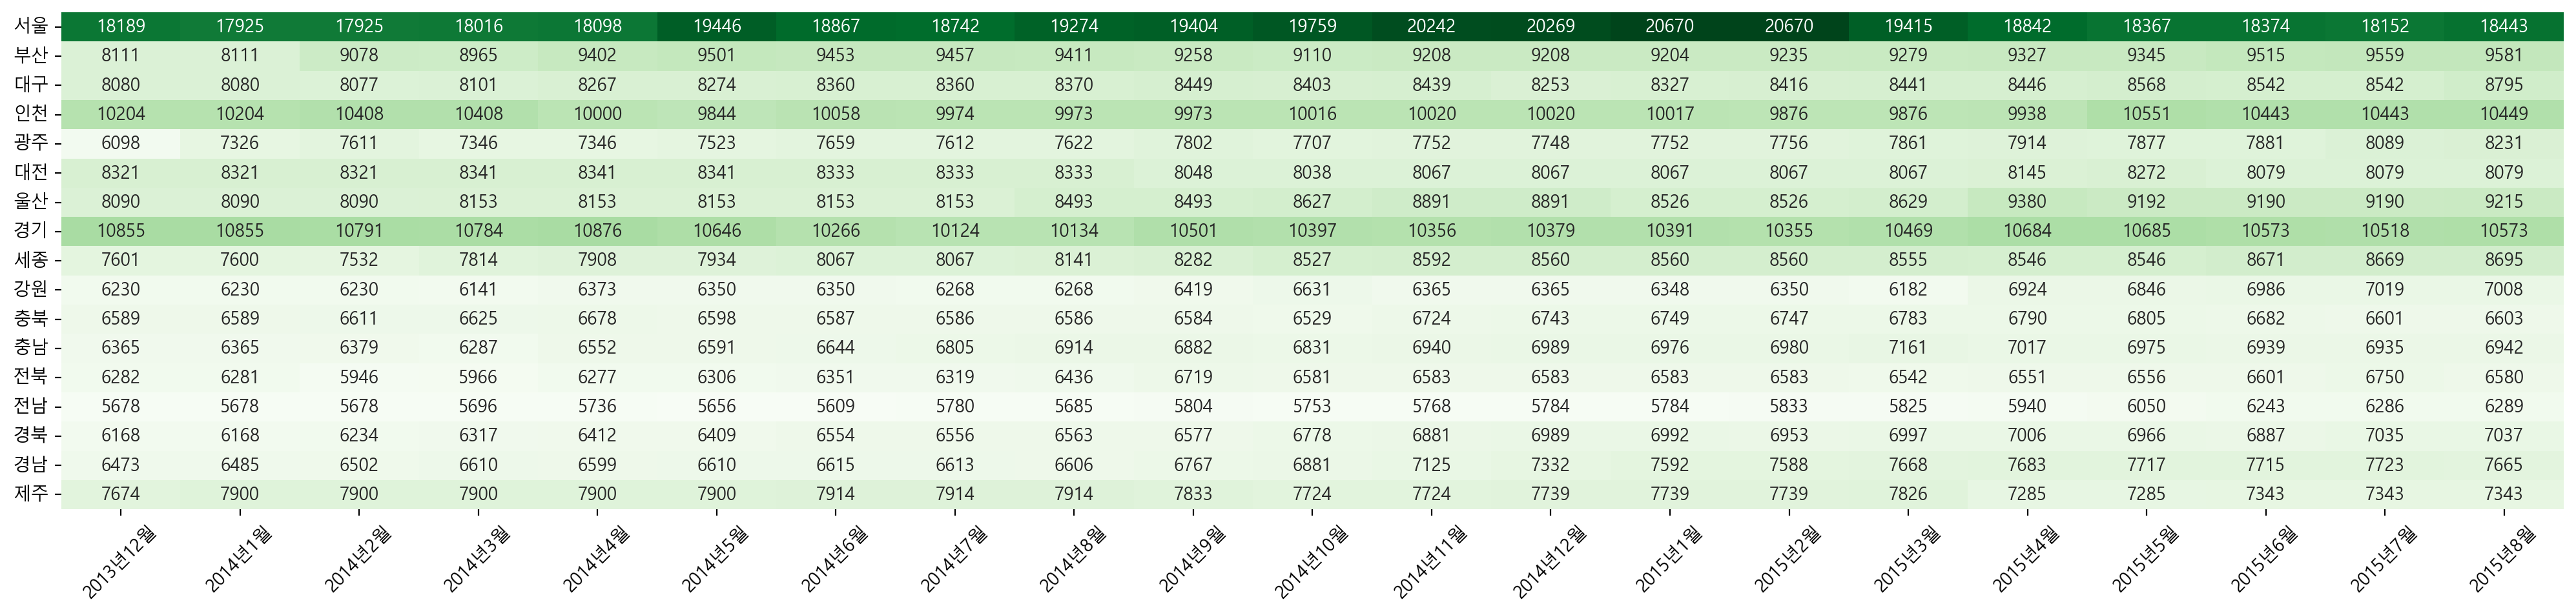

In [8]:
plt.figure(figsize=(25,5))
sns.heatmap(df_first,annot=True, fmt='d',cmap='Greens',cbar=False)
plt.xticks(rotation=45)
plt.ylabel(None)
plt.show()

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

 ### 2015이후 데이터 분양가격에 간헐적으로 comma(,) 추가하여 csv로 출력
  --> 제외


In [9]:
# isna(), isnull() - 결측치 여부
# notnull(), notna() - 결측치가 아닌지 여부


In [10]:
# 분양가격(제곱미터당 천원)가 결측치인 행 상위2개


In [11]:
# 분양가격(제곱미터당 천원) 컬럼의 type을 float64로 타입 변환 : astype(), pd.to_numeric()


In [12]:
# 분양가격(제곱미터당 천원) 컬럼이 space인 행


In [13]:
# 분양가격이 nan이거나 space면 0, 그외 분양가격의 문자자리수를 return하는 함수
def get_pricelen(row):
    pass


In [14]:
# 2020년전 데이터 흉내내기 위한 함수  : nan, ' ', '  ', '5123', '5,123'
def comma_append(row):
    pass

In [15]:
# 간헐적으로 평당분양가에 ,가 있거나 np.nan이 있거나 space가 있는 데이터 csv로 백업

## (2) 이후 데이터는 df_last 변수에 담아 탐색

In [73]:
df_last=pd.read_csv('c:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531 (3).csv',encoding='cp949')
df_last.tail()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
10875,제주,모든면적,2026,5,4473
10876,제주,전용면적 60제곱미터이하,2026,5,NaN
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN
10879,제주,전용면적 102제곱미터초과,2026,5,4350


In [17]:
# 데이터 요약하기
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   지역명             10880 non-null  object
 1   규모구분            10880 non-null  object
 2   연도              10880 non-null  int64 
 3   월               10880 non-null  int64 
 4   분양가격(제곱미터당 천원)  10035 non-null  object
dtypes: int64(2), object(3)
memory usage: 425.1+ KB


In [18]:
df_last['분양가격(제곱미터당 천원)'].describe()

count     10035
unique     3637
top            
freq         95
Name: 분양가격(제곱미터당 천원), dtype: object

# 3. df_last의 데이터 결측치를 확인하고 대체 고민

In [37]:
float('5841'),float(np.nan) #숫자열문자 나 결측치는 float로 형변환 가능하다

(5841.0, nan)

In [44]:
#df_last['분양가격(제곱미터당 천원)'].astype('float64')  space*2 항목있어 변환안됨
pd.to_numeric(df_last['분양가격(제곱미터당 천원)'], errors='coerce').isna().sum()  #coerce : error항목 발생시 Nan으로 입력됨
#결측치원래 nan 845 / 스페이스입력데이터126 (엉뚱한 data들 but 5,000 같은 data는 살려야한다) 128  '-'나머지2개

973

In [49]:
temp=pd.to_numeric(df_last['분양가격(제곱미터당 천원)'], errors='coerce')
nanidx=temp[temp.isna()].index
nanidx

Int64Index([   28,    29,    34,    81,   113,   114,   119,   166,   198,
              199,
            ...
            10793, 10816, 10818, 10823, 10838, 10839, 10858, 10863, 10876,
            10878],
           dtype='int64', length=973)

In [50]:
df_last.loc[nanidx,'분양가격(제곱미터당 천원)'].unique()

array(['  ', nan, ' ', '-'], dtype=object)

In [51]:
df_last[df_last['분양가격(제곱미터당 천원)']=='-'].shape[0]  

2

In [29]:
# 열별 결측치 갯수
df_last.isna()
df_last.isna().sum()

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
10875,False,False,False,False,False
10876,False,False,False,False,True
10877,False,False,False,False,False
10878,False,False,False,False,True


In [56]:
# 열별 결측치를 제외한 갯수
df_last.notna().sum()

지역명               10880
규모구분              10880
연도                10880
월                 10880
분양가격(제곱미터당 천원)    10035
dtype: int64

In [32]:
#결측치인 행 :368,.....
type(np.nan)
df_last[df_last['분양가격(제곱미터당 천원)'].isna()].shape[0]

845

In [48]:
############################   str.strip 문자열 사용이고 시리즈 사용시 str을 붙인다
#df_last[df_last['분양가격(제곱미터당 천원)']==np.nan].shape[0]  
# ' '인행이 126개
df_last[df_last['분양가격(제곱미터당 천원)'].str.strip()=='']

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
28,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,10,
29,광주,전용면적 102제곱미터초과,2015,10,
34,대전,전용면적 102제곱미터초과,2015,10,
81,제주,전용면적 60제곱미터이하,2015,10,
113,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,11,
...,...,...,...,...,...
8833,경남,전용면적 85제곱미터초과 102제곱미터이하,2024,5,
8836,제주,전용면적 60제곱미터이하,2024,5,
8838,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,5,
8964,울산,전용면적 102제곱미터초과,2024,7,


# 4. df_last 데이셋에 평당분양가격컬럼 추가

## (1) astype('float')나 pd.to_numeric() 사용
## (2) 6,222 => 6222 수정 후, 형변환
## (3) df_last['분양가격(제곱미터)']*3.3

### apply
- apply(func,axis) : 1차원, 2차원(axis지정. 기본값0=열단위 작업(1=행단위 작업)


In [52]:
# 콤마가 있는 문자에서 콤마 없애기 방법
temp = '12,523'
temp.replace(',','')

'12523'

In [78]:
df_last.loc[8834]

지역명                           경남
규모구분              전용면적 102제곱미터초과
연도                          2024
월                              5
분양가격(제곱미터당 천원)              4396
Name: 8834, dtype: object

In [79]:
# 분양가격 컬럼에 콤마(,)가 있는 경우 콤마(,)를 제거('5,123' -> '5123')
# 공백문자가 있는 경우 np.nan로 바꾸는 함수
def commadrop(row):
    row = row.copy()
    price =row['분양가격(제곱미터당 천원)']
    #np.isnan(스칼라값) : 값이 숫자일 경우만 에러나지않고, np.nan 결측치 여부 반환
    #pd.isna, pd.isnull(스칼라값) : 값의 타입에 상관없이 np.nan과 None인지 여부 반환 
    if pd.isna(price): # 결측치인지 여부
        row['제곱미터당분양가격'] =np.nan
    elif price.strip() == '' or price=='-': #space거나 -이면 결측치
        row['제곱미터당분양가격'] = np.nan
    elif price.find(',') != -1 :
        row['제곱미터당분양가격'] = float(price.replace(',',''))
    else :
        row['제곱미터당분양가격'] = float(price)      
    return row

commadrop(df_last.loc[0]) # 콤마 제외
commadrop(df_last.loc[1]) # 그대로
commadrop(df_last.loc[28]) # 공백문자의 경우 nan

commadrop(df_last.loc[368]) # nan의 경우 nan
commadrop(df_last.loc[8863]) #-인경우

지역명                                    대구
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2024
월                                       6
분양가격(제곱미터당 천원)                          -
제곱미터당분양가격                             NaN
Name: 8863, dtype: object

In [83]:
# 공백문자는 결측치로, 콤마는 제거하기를 모든 행에 적용
df_last= df_last.apply(commadrop,axis=1)
df_last

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),제곱미터당분양가격
0,서울,모든면적,2015,10,5841,5841.0
1,서울,전용면적 60제곱미터이하,2015,10,5652,5652.0
2,서울,전용면적 60제곱미터초과 85제곱미터이하,2015,10,5882,5882.0
3,서울,전용면적 85제곱미터초과 102제곱미터이하,2015,10,5721,5721.0
4,서울,전용면적 102제곱미터초과,2015,10,5879,5879.0
...,...,...,...,...,...,...
10875,제주,모든면적,2026,5,4473,4473.0
10876,제주,전용면적 60제곱미터이하,2026,5,NaN,NaN
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485,4485.0
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN,NaN


In [84]:
df_last[['분양가격(제곱미터당 천원)', '제곱미터당분양가격']].isna().sum()

분양가격(제곱미터당 천원)    845
제곱미터당분양가격         973
dtype: int64

### map

In [70]:
df_last.drop(['제곱미터당분양가격'], axis=1, inplace=True)
df_last.sample(1)

,지역명,규모구분,연도,월
4151,경북,전용면적 60제곱미터이하,2019,10


In [89]:
# 결측치->결측치 return, 공백문자->결측치 return, '3,198' -> 3198 return, '3198'->3198 return,  
def commadrop2(price):
    #np.isnan(스칼라값) : 값이 숫자일 경우만 에러나지않고, np.nan 결측치 여부 반환
    #pd.isna, pd.isnull(스칼라값) : 값의 타입에 상관없이 np.nan과 None인지 여부 반환 
    if pd.isna(price): # 결측치인지 여부
        return np.nan
    elif price.strip() == '' or price=='-': #space거나 -이면 결측치
        return np.nan
    elif price.find(',') != -1 :
        return float(price.replace(',',''))
    else :
        return float(price)      

commadrop2(df_last.loc[0, '분양가격(제곱미터당 천원)']) # 콤마제외한 문자를 숫자로 
commadrop2(df_last.loc[1, '분양가격(제곱미터당 천원)']) # 콤마없는 문자를 숫자로 
commadrop2(df_last.loc[28, '분양가격(제곱미터당 천원)']) # 공백문자를 nan
commadrop2(df_last.loc[368, '분양가격(제곱미터당 천원)']) # nan을 nan

nan

- apply(함수, axis) : 1차원, 2차원(axis 지정. axis기본값0)
- map(함수) : 1차원
- applymap(함수) : 2차원(모든 요소들에 함수를 적용)

In [91]:
df_last['분양가격(제곱미터당 천원)'].apply(commadrop2)
df_last['제곱미터당분양가격'] = df_last['분양가격(제곱미터당 천원)'].map(commadrop2)
df_last.head(3)
df_last.iloc[8863:8867]  # -인데이터가 Nan으로 변경 확인됨

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),제곱미터당분양가격
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-,NaN
8864,대구,전용면적 102제곱미터초과,2024,6,5593,5593.0
8865,광주,모든면적,2024,6,5471,5471.0
8866,광주,전용면적 60제곱미터이하,2024,6,6504,6504.0


###    apply /map 사용안하기 


In [95]:
pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''),errors='coerce').isna().sum()

973

In [96]:
df_last['제곱미터당분양가격']=pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''),errors='coerce')
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당분양가격       9907 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 510.1+ KB


In [97]:
#형변형 후 평당분양가격    제곱미터당 분양가격*3.3 -> 평당분양가격
df_last['평당분양가격']=df_last['제곱미터당분양가격']*3.3
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당분양가격       9907 non-null   float64
 6   평당분양가격          9907 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 595.1+ KB


In [98]:
df_last[['제곱미터당분양가격','평당분양가격']].describe() #요약통계량

,제곱미터당분양가격,평당분양가격
count,9907.000000,9907.000000
mean,4291.544867,14162.098062
std,2125.581720,7014.419675
min,1868.000000,6164.400000
25%,2872.000000,9477.600000
50%,3798.000000,12533.400000
75%,4940.500000,16303.650000
max,22713.000000,74952.900000


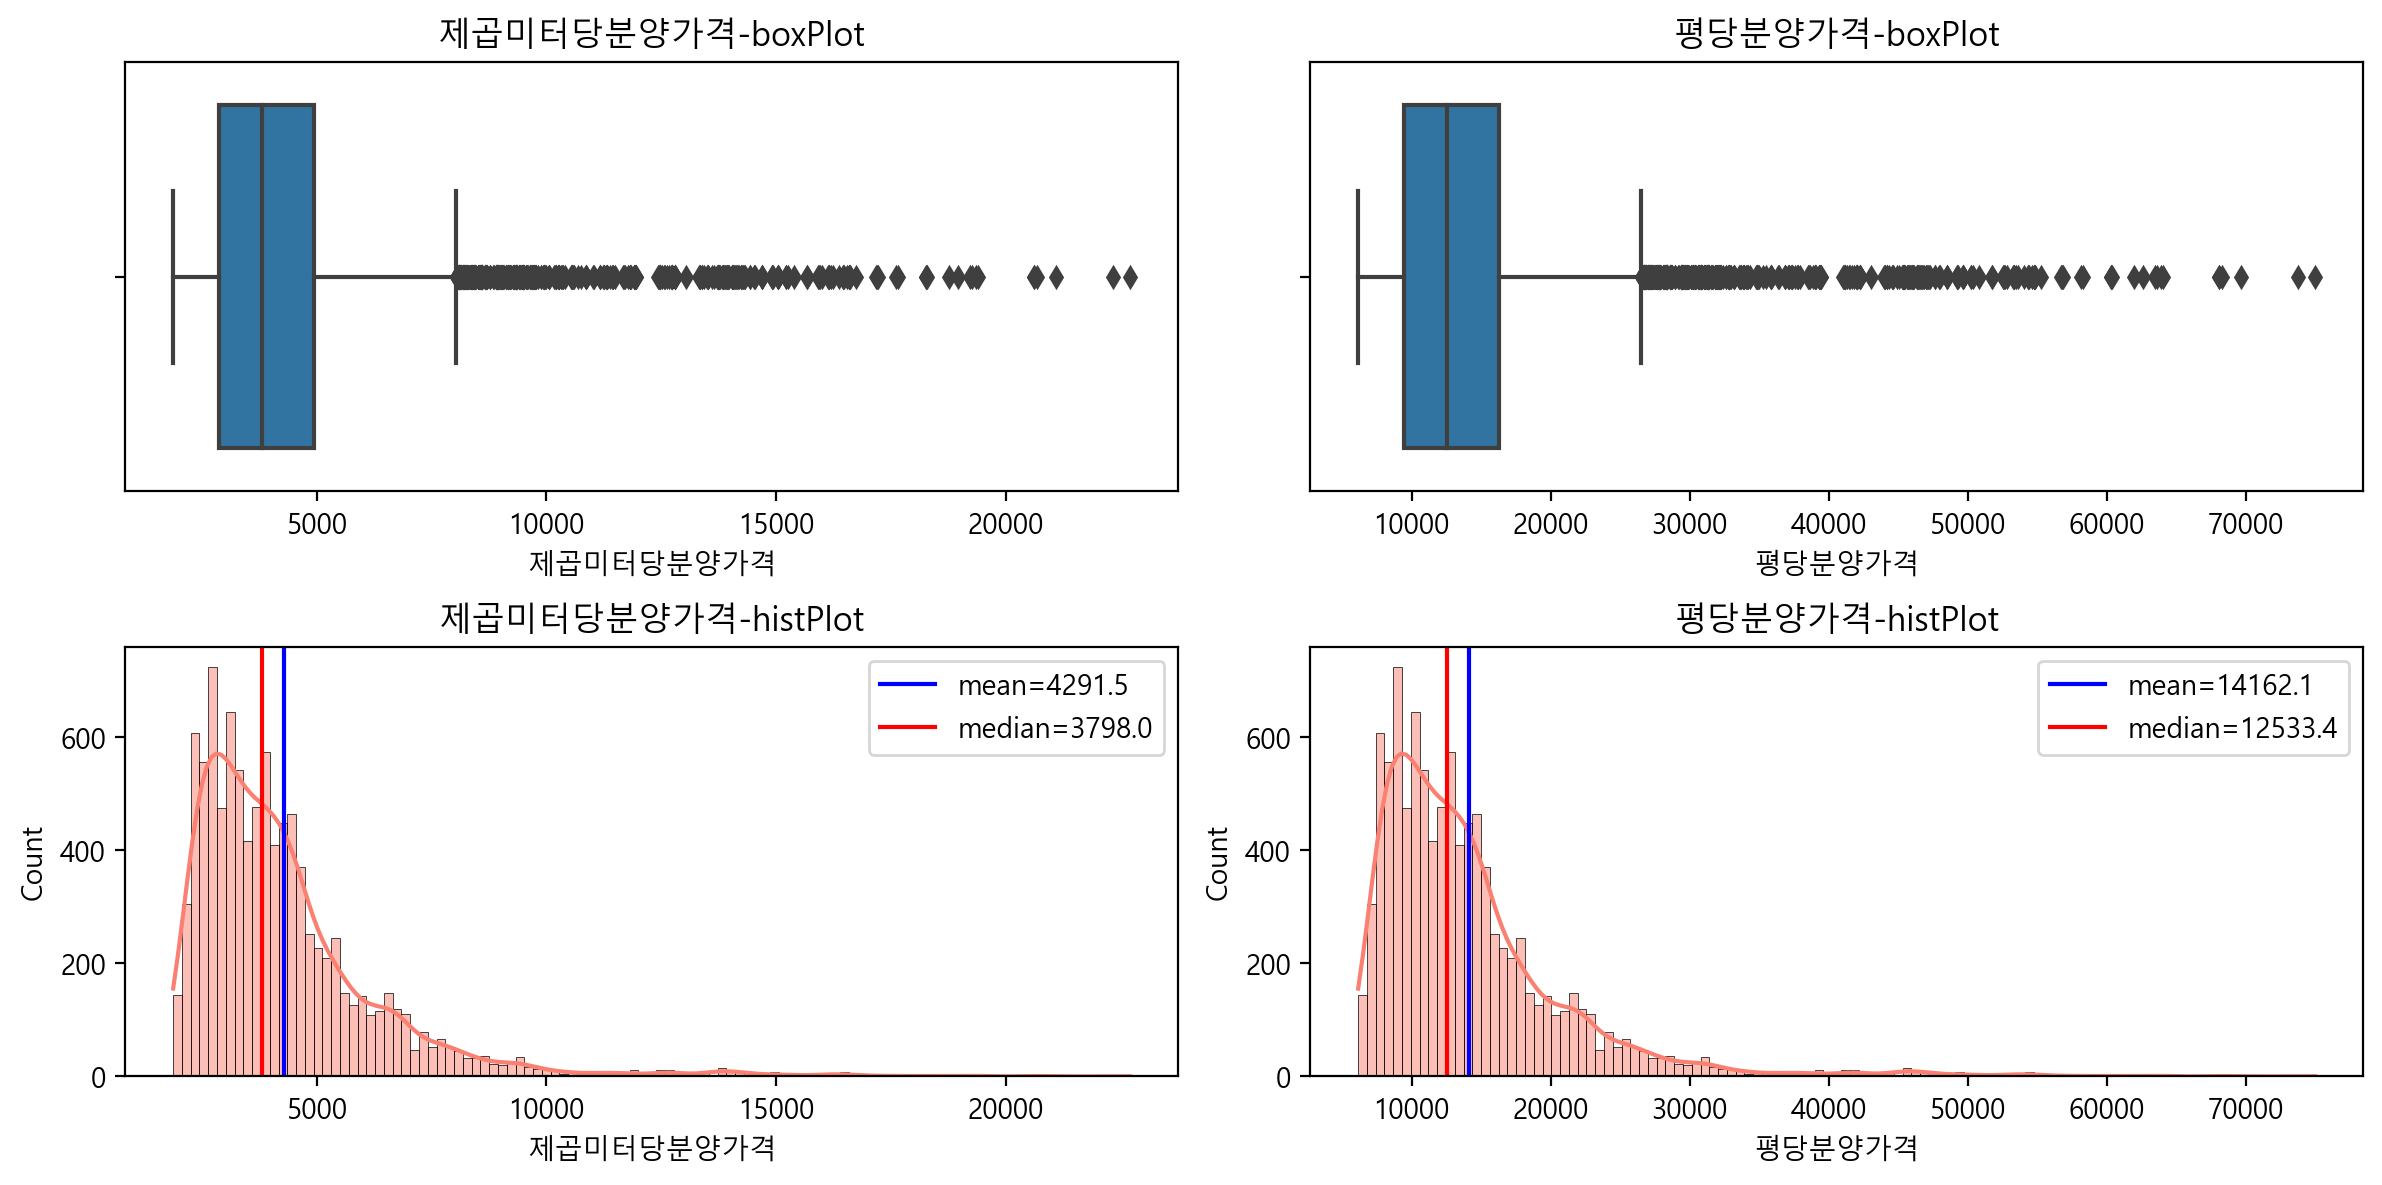

In [118]:
cols =['제곱미터당분양가격','평당분양가격']
fig, axes = plt.subplots(nrows=2, ncols=len(cols), figsize=(12,6))
for i, col in enumerate(cols):
    #0행 boxplot
    sns.boxplot(data=df_last,x=col, ax=axes[0,i])
    axes[0,i].set_title(f'{col}-boxPlot')
    #1행 histplot
    sns.histplot(df_last[col], ax=axes[1,i],color='salmon',kde=True)
    axes[1,i].set_title(f'{col}-histPlot')
    #평균(mean)과 중위수(median)를 histplot 표시
    mean_val=df_last[col].mean()
    median_val=df_last[col].median()
    axes[1,i].axvline(mean_val,color='blue',label=f'mean={mean_val:.1f}')
    axes[1,i].axvline(median_val,color='red',label=f'median={median_val:.1f}')
    axes[1,i].legend()
plt.tight_layout()

In [119]:
#왜도(skewness) : 분포가 좌우로 얼마나 비대칭인지를 수치로 나타내는 지표
#왜도 = 0 : 완벽한 좌우대칭 / |왜도|< 0.5 : 거의 대칭
#왜도 > 0 : 오른쪽 꼬리 긴 분포 (mean > median)
#왜도 < 0 : 왼쪽 꼬리 긴 분포 (mean < median)

df_last[['제곱미터당분양가격']].skew()  #심한 오른쪽 꼬리 긴 분포

제곱미터당분양가격    2.582328
dtype: float64

# 5. df_last 데이터셋에서 전용면적 컬럼을 추가한다
- 전용면적 컬럼, 필요없는 컬럼 처리로 메모리 절약

In [121]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당분양가격       9907 non-null   float64
 6   평당분양가격          9907 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 595.1+ KB


In [125]:
df_last['규모구분'].unique()

array(['모든면적', '전용면적 60제곱미터이하', '전용면적 60제곱미터초과 85제곱미터이하',
       '전용면적 85제곱미터초과 102제곱미터이하', '전용면적 102제곱미터초과'], dtype=object)

In [ ]:
#² :alt+0178 Alt떼기 
#전용면적 60제곱미터초과 85제곱미터이하 -> 60m~85m

In [134]:
df_last['전용면적']= df_last['규모구분'].str.replace('전용면적','').str.replace('이하','').str.replace('제곱미터','m')
df_last['전용면적']=df_last['전용면적'].str.replace('초과','~')
df_last['전용면적']=df_last['전용면적'].str.replace(' ','')
df_last['전용면적']

0            모든면적
1             60m
2         60m~85m
3        85m~102m
4           102m~
           ...   
10875        모든면적
10876         60m
10877     60m~85m
10878    85m~102m
10879       102m~
Name: 전용면적, Length: 10880, dtype: object

In [138]:
df_last['전용면적'].unique()

array(['모든면적', '60m', '60m~85m', '85m~102m', '102m~'], dtype=object)

# 6. 메모리 사용량을 줄이기 위해 불필요한 컬럼 제거

In [143]:
df_last.drop(['규모구분','분양가격(제곱미터당 천원)','제곱미터당분양가격'],axis=1,inplace=True) #열삭제후 데이터 return

In [146]:
df_last.head(1)

,지역명,연도,월,평당분양가격,전용면적
0,서울,2015,10,19275.3,모든면적


In [147]:
# df_last[['지역명','전용면적','연도','연도','월','평당분양가격']]
# df_last.reindex(columns=['지역명','전용면적','연도','연도','월','평당분양가격'])
col=df_last.pop('전용면적')
print(col)
df_last

0            모든면적
1             60m
2         60m~85m
3        85m~102m
4           102m~
           ...   
10875        모든면적
10876         60m
10877     60m~85m
10878    85m~102m
10879       102m~
Name: 전용면적, Length: 10880, dtype: object


,지역명,연도,월,평당분양가격
0,서울,2015,10,19275.3
1,서울,2015,10,18651.6
2,서울,2015,10,19410.6
3,서울,2015,10,18879.3
4,서울,2015,10,19400.7
...,...,...,...,...
10875,제주,2026,5,14760.9
10876,제주,2026,5,NaN
10877,제주,2026,5,14800.5
10878,제주,2026,5,NaN


In [148]:
df_last.insert(1,'전용면적',col)
df_last.head()

,지역명,전용면적,연도,월,평당분양가격
0,서울,모든면적,2015,10,19275.3
1,서울,60m,2015,10,18651.6
2,서울,60m~85m,2015,10,19410.6
3,서울,85m~102m,2015,10,18879.3
4,서울,102m~,2015,10,19400.7


In [149]:
df_last.to_csv('data/df_last.csv', index=False) # 전처리 단계 백업

※

# 7. 데이터 집계
- GroupBy(unstack()함수 이용) vs. pivot_table()
- GroupBy가 조금 시간이 적게 걸릴 수 있음
- 우선 결측치 대체전 데이터 집계와 시각화를 할 예정

In [ ]:
df_last=pd.read_csv('data/df_last.csv')
df_last.head(1)

- df_last.groupby(["인덱스로사용할컬럼명"])["계산할컬럼명"].연산함수()
- df_last.pivot_table(index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")
- pd.pivot_table(df_last, index=["인덱스로사용할컬럼명"],
                    values=["계산할컬럼명"],
                    aggfunc="연산함수명")

## (1) 지역별 데이터수

In [160]:
#지역별 결측치 포함한 데이터(행)수
df_last.groupby('지역명')['전용면적'].count()
df_last['지역명'].value_counts()# 정렬까지

서울    640
강원    640
경남    640
경북    640
전남    640
전북    640
충남    640
충북    640
세종    640
인천    640
울산    640
대전    640
광주    640
대구    640
부산    640
경기    640
제주    640
Name: 지역명, dtype: int64

In [175]:
#지역별 결측치를  제외한 데이터(행)수 
#df_last.groupby('지역명')['평당분양가격'].count().sort_values('평당분양가격', ascending=False) #1차원
#df_last.groupby('지역명')[['평당분양가격']].count().sort_values('평당분양가격', ascending=False).head() #2차원

In [176]:
df_last.groupby('지역명')[['평당분양가격']].count().sort_values('평당분양가격', ascending=False).head(1)

,평당분양가격
지역명,
경기,640


In [ ]:
#지역별 결측치를  제외한 데이터(행)수  ##pd.pivot_table(df,index,values,aggfunc) 

In [177]:
df_last.pivot_table(index='지역명',values='평당분양가격',aggfunc='count').sort_values('평당분양가격', ascending=False).head(1)
# pd.pivot_table(df_last,'지역명','평당')

,평당분양가격
지역명,
경기,640


## (2) 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [182]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False).head(1)

지역명
서울    31416.731013
Name: 평당분양가격, dtype: float64

In [188]:
df_last.pivot_table(index='지역명',values='평당분양가격').sort_values(by='평당분양가격', ascending=False).round(1).T

지역명,서울,경기,부산,제주,대구,인천,울산,대전,광주,세종,경남,강원,경북,충남,전남,충북,전북
평당분양가격,31416.7,16675.8,16658.9,16537.0,15951.4,15378.6,14932.2,14177.8,14003.6,11442.1,11322.6,10998.0,10838.5,10492.3,9784.7,9765.3,9568.7


In [191]:
df_last.pivot_table(index='지역명',values='평당분양가격').sort_values(by='평당분양가격', 
                                                             ascending=False).applymap(lambda x: int(round(x))).T

지역명,서울,경기,부산,제주,대구,인천,울산,대전,광주,세종,경남,강원,경북,충남,전남,충북,전북
평당분양가격,31417,16676,16659,16537,15951,15379,14932,14178,14004,11442,11323,10998,10839,10492,9785,9765,9569


In [200]:
#지역별 요약 통계량(describe)
df_last.groupby('지역명')['평당분양가격'].describe(include=all)

,count,mean,std,min,25%,50%,75%,max
지역명,,,,,,,,
강원,628.0,10998.011943,3425.702338,6639.6,7877.100,10269.60,14201.550,31016.7
경기,640.0,16675.776562,4178.250807,10160.7,13600.125,15486.90,20549.925,28960.8
경남,609.0,11322.646798,2457.789421,7260.0,9428.100,10596.30,13460.700,18196.2
경북,592.0,10838.521115,2589.517973,6949.8,8507.400,10292.70,13299.000,17160.0
광주,545.0,14003.631743,4244.071441,7428.3,10045.200,13919.40,17239.200,39029.1
대구,582.0,15951.406186,5304.075909,8259.9,12412.125,15387.90,17019.750,42220.2
대전,513.0,14177.752047,5212.274642,8002.5,10101.300,13427.70,17351.400,52813.2
부산,635.0,16658.924882,5948.934616,9669.0,12647.250,14265.90,20676.150,42220.2
서울,632.0,31416.731013,10674.077285,16701.3,23064.525,28297.50,35818.200,74952.9


In [202]:
#지역별 요약 통계량(describe)
df_last.groupby('지역명')[['평당분양가격']].max().sort_values(by='평당분양가격', ascending=False).T

지역명,서울,인천,대전,부산,대구,광주,강원,경기,제주,울산,세종,경남,충남,충북,경북,전북,전남
평당분양가격,74952.9,64010.1,52813.2,42220.2,42220.2,39029.1,31016.7,28960.8,27753.0,27188.7,19813.2,18196.2,17724.3,17166.6,17160.0,16001.7,15143.7


In [203]:
df_last.pivot_table(index='지역명',values='평당분양가격',aggfunc='max').sort_values(by='평당분양가격', 
                                                             ascending=False).T

지역명,서울,인천,대전,부산,대구,광주,강원,경기,제주,울산,세종,경남,충남,충북,경북,전북,전남
평당분양가격,74952.9,64010.1,52813.2,42220.2,42220.2,39029.1,31016.7,28960.8,27753.0,27188.7,19813.2,18196.2,17724.3,17166.6,17160.0,16001.7,15143.7


In [212]:
r=df_last.pivot_table(index=['지역명'],values=['평당분양가격'],aggfunc='describe').round(2)
r.columns=r.columns.droplevel(0)
r

,25%,50%,75%,count,max,mean,min,std
지역명,,,,,,,,
강원,7877.10,10269.60,14201.55,628.0,31016.7,10998.01,6639.6,3425.70
경기,13600.12,15486.90,20549.92,640.0,28960.8,16675.78,10160.7,4178.25
경남,9428.10,10596.30,13460.70,609.0,18196.2,11322.65,7260.0,2457.79
경북,8507.40,10292.70,13299.00,592.0,17160.0,10838.52,6949.8,2589.52
광주,10045.20,13919.40,17239.20,545.0,39029.1,14003.63,7428.3,4244.07
대구,12412.12,15387.90,17019.75,582.0,42220.2,15951.41,8259.9,5304.08
대전,10101.30,13427.70,17351.40,513.0,52813.2,14177.75,8002.5,5212.27
부산,12647.25,14265.90,20676.15,635.0,42220.2,16658.92,9669.0,5948.93
서울,23064.52,28297.50,35818.20,632.0,74952.9,31416.73,16701.3,10674.08


## (3) 전용면적별 평당분양가격(평균)

In [219]:
df_last.groupby('전용면적')[['평당분양가격']].mean().sort_values('평당분양가격',ascending=False).round(1) #2차원

,평당분양가격
전용면적,
102m~,15348.9
85m~102m,14554.5
모든면적,13783.4
60m~85m,13710.9
60m,13553.3


In [220]:
df_last.groupby('전용면적')['평당분양가격'].mean().sort_values(ascending=False).round(1) #1차원

전용면적
102m~       15348.9
85m~102m    14554.5
모든면적        13783.4
60m~85m     13710.9
60m         13553.3
Name: 평당분양가격, dtype: float64

In [221]:
df_last.groupby('전용면적')['평당분양가격'].mean().sort_values(ascending=False).round(1).to_frame #2차원

<bound method Series.to_frame of 전용면적
102m~       15348.9
85m~102m    14554.5
모든면적        13783.4
60m~85m     13710.9
60m         13553.3
Name: 평당분양가격, dtype: float64>

In [223]:
df_last.pivot_table(index='전용면적',values='평당분양가격').sort_values('평당분양가격',ascending=False).round(1).T

전용면적,102m~,85m~102m,모든면적,60m~85m,60m
평당분양가격,15348.9,14554.5,13783.4,13710.9,13553.3


## (4) 지역별, 전용면적별 평당분양가격(평균)

In [236]:
r= df_last.groupby(['지역명','전용면적'])['평당분양가격'].mean()#2차원
display(r['경기'])
print(r['경기','102m~'])

전용면적
102m~       17356.195312
60m         16698.567188
60m~85m     16133.313281
85m~102m    17134.992188
모든면적        16055.814844
Name: 평당분양가격, dtype: float64

17356.1953125


In [250]:
#unstack(): level 0 인덱스는 그대로 두고, level1인덱스를 컬럼으로 
df_last.groupby(['지역명','전용면적'])['평당분양가격'].mean().unstack().round()

전용면적,102m~,60m,60m~85m,85m~102m,모든면적
지역명,,,,,
강원,12191.0,10465.0,10286.0,11666.0,10445.0
경기,17356.0,16699.0,16133.0,17135.0,16056.0
경남,12083.0,10691.0,10798.0,12413.0,10840.0
경북,11742.0,10121.0,10523.0,11292.0,10568.0
광주,16203.0,13326.0,13423.0,12827.0,13766.0
대구,17565.0,14180.0,16226.0,14913.0,16466.0
대전,19628.0,12670.0,12887.0,15296.0,12978.0
부산,17995.0,15796.0,16149.0,17111.0,16276.0
서울,33910.0,30758.0,30337.0,31873.0,30331.0


In [257]:
r=df_last.pivot_table(index=['지역명','전용면적'],values='평당분양가격',aggfunc='mean').unstack()
r.columns=r.columns.droplevel(0)
r

전용면적,102m~,60m,60m~85m,85m~102m,모든면적
지역명,,,,,
강원,12190.664062,10464.867188,10286.306250,11665.613793,10445.196094
경기,17356.195312,16698.567188,16133.313281,17134.992188,16055.814844
경남,12082.530508,10690.978571,10797.883594,12413.298165,10839.932812
경북,11741.980800,10120.955263,10522.849219,11291.545361,10567.682812
광주,16202.855263,13326.445000,13423.291406,12826.980000,13765.743750
대구,17564.800000,14179.645872,16225.545600,14912.832000,16465.521600
대전,19627.533750,12669.992500,12886.525781,15295.847368,12978.487500
부산,17994.742857,15796.017187,16148.653125,17111.133600,16275.548437
서울,33909.528689,30757.778906,30337.003125,31872.657143,30330.660938


In [270]:
## 다른 방법 추천
r=df_last.pivot_table(index='지역명',columns='전용면적',values='평당분양가격').round().reindex(columns=['60m','60m~85m','85m~102m','102m~','모든면적'])
##column 순서
#r=r[['60m','60m~85m','85m~102m','102m~','모든면적']]
r


전용면적,60m,60m~85m,85m~102m,102m~,모든면적
지역명,,,,,
강원,10465.0,10286.0,11666.0,12191.0,10445.0
경기,16699.0,16133.0,17135.0,17356.0,16056.0
경남,10691.0,10798.0,12413.0,12083.0,10840.0
경북,10121.0,10523.0,11292.0,11742.0,10568.0
광주,13326.0,13423.0,12827.0,16203.0,13766.0
대구,14180.0,16226.0,14913.0,17565.0,16466.0
대전,12670.0,12887.0,15296.0,19628.0,12978.0
부산,15796.0,16149.0,17111.0,17995.0,16276.0
서울,30758.0,30337.0,31873.0,33910.0,30331.0


<Axes: xlabel='전용면적', ylabel='지역명'>

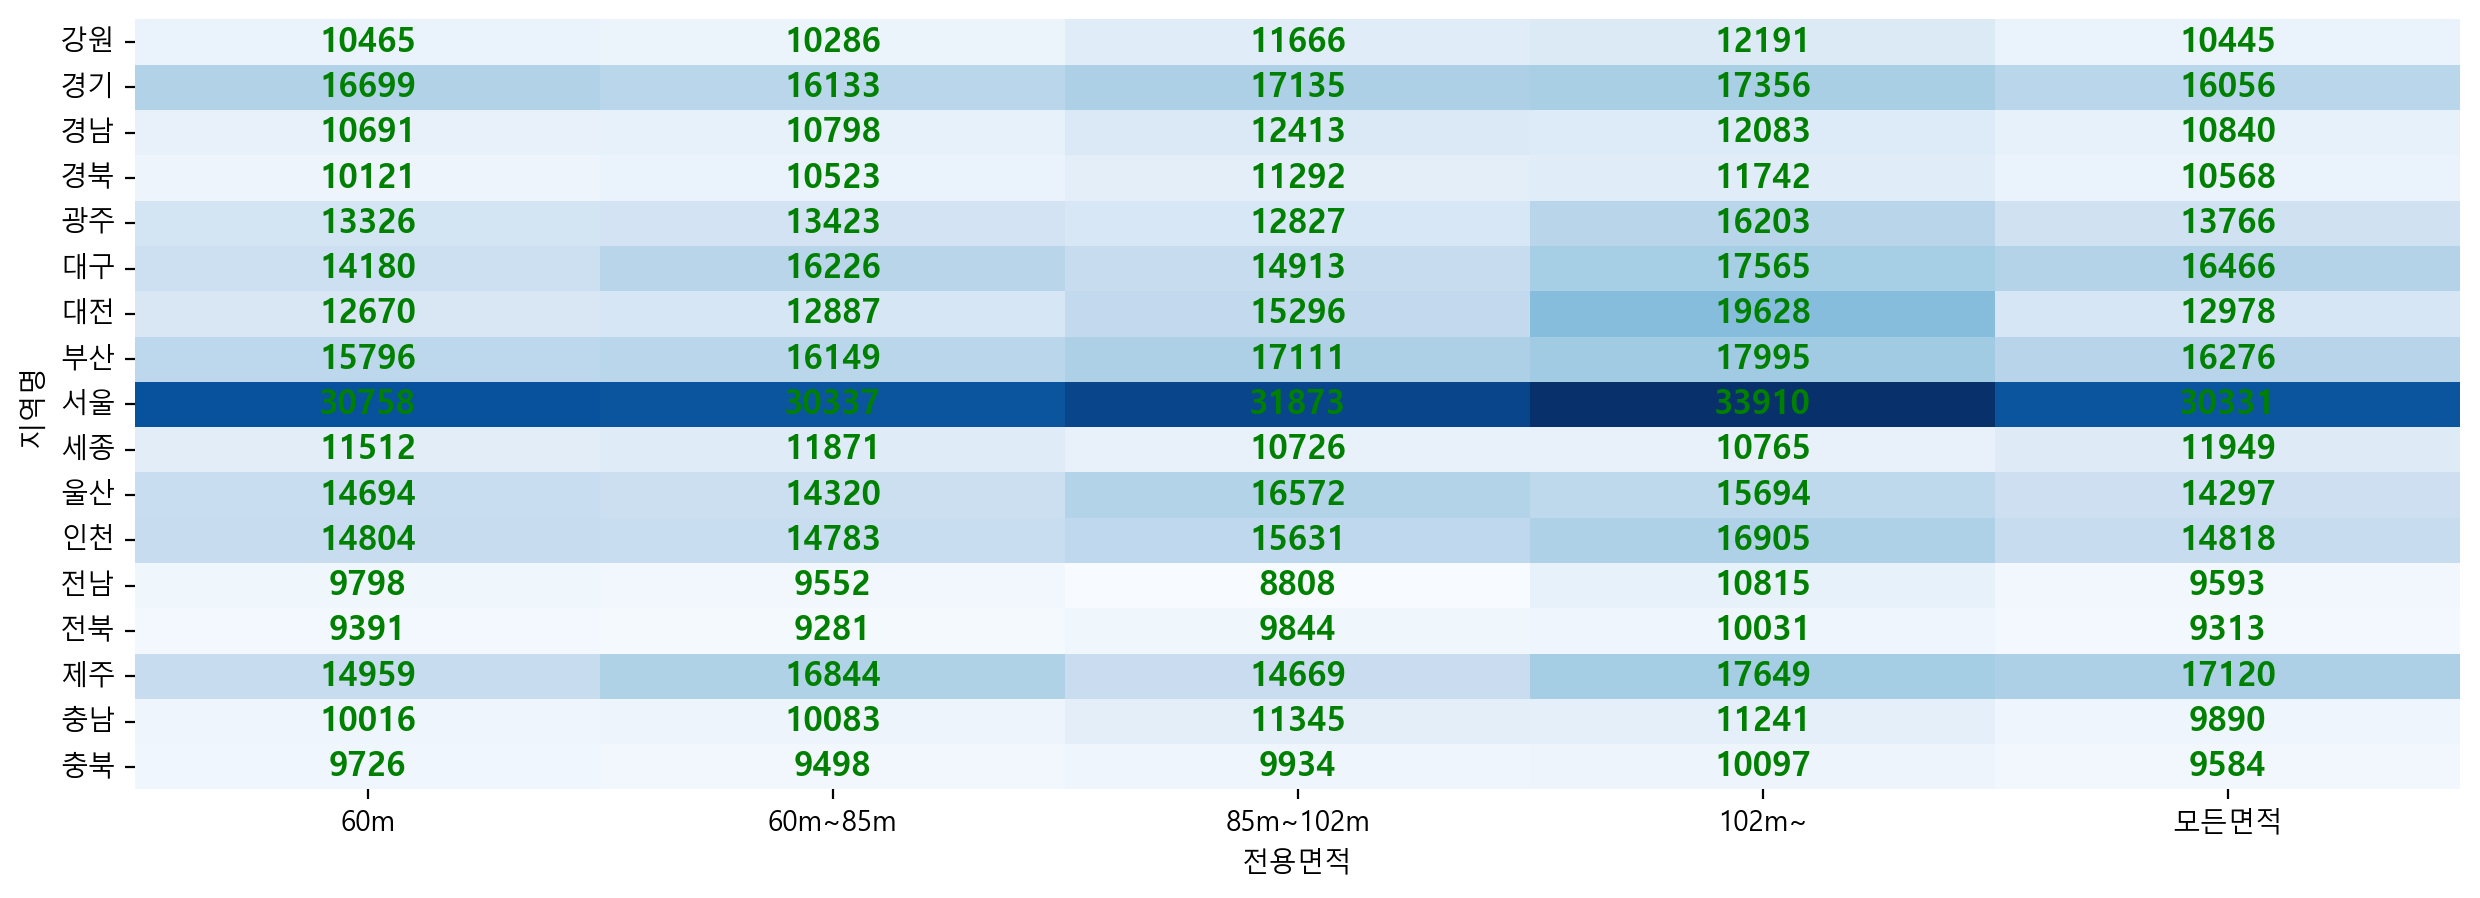

In [275]:
plt.figure(figsize=(15,5))
sns.heatmap(r,annot=True,fmt='.0f',cmap='Blues',annot_kws={'color':'green','size':12, 'weight':'bold'},cbar=False)

## (5) 연도, 지역별 평당분양가격(평균)

<Axes: xlabel='지역명', ylabel='연도'>

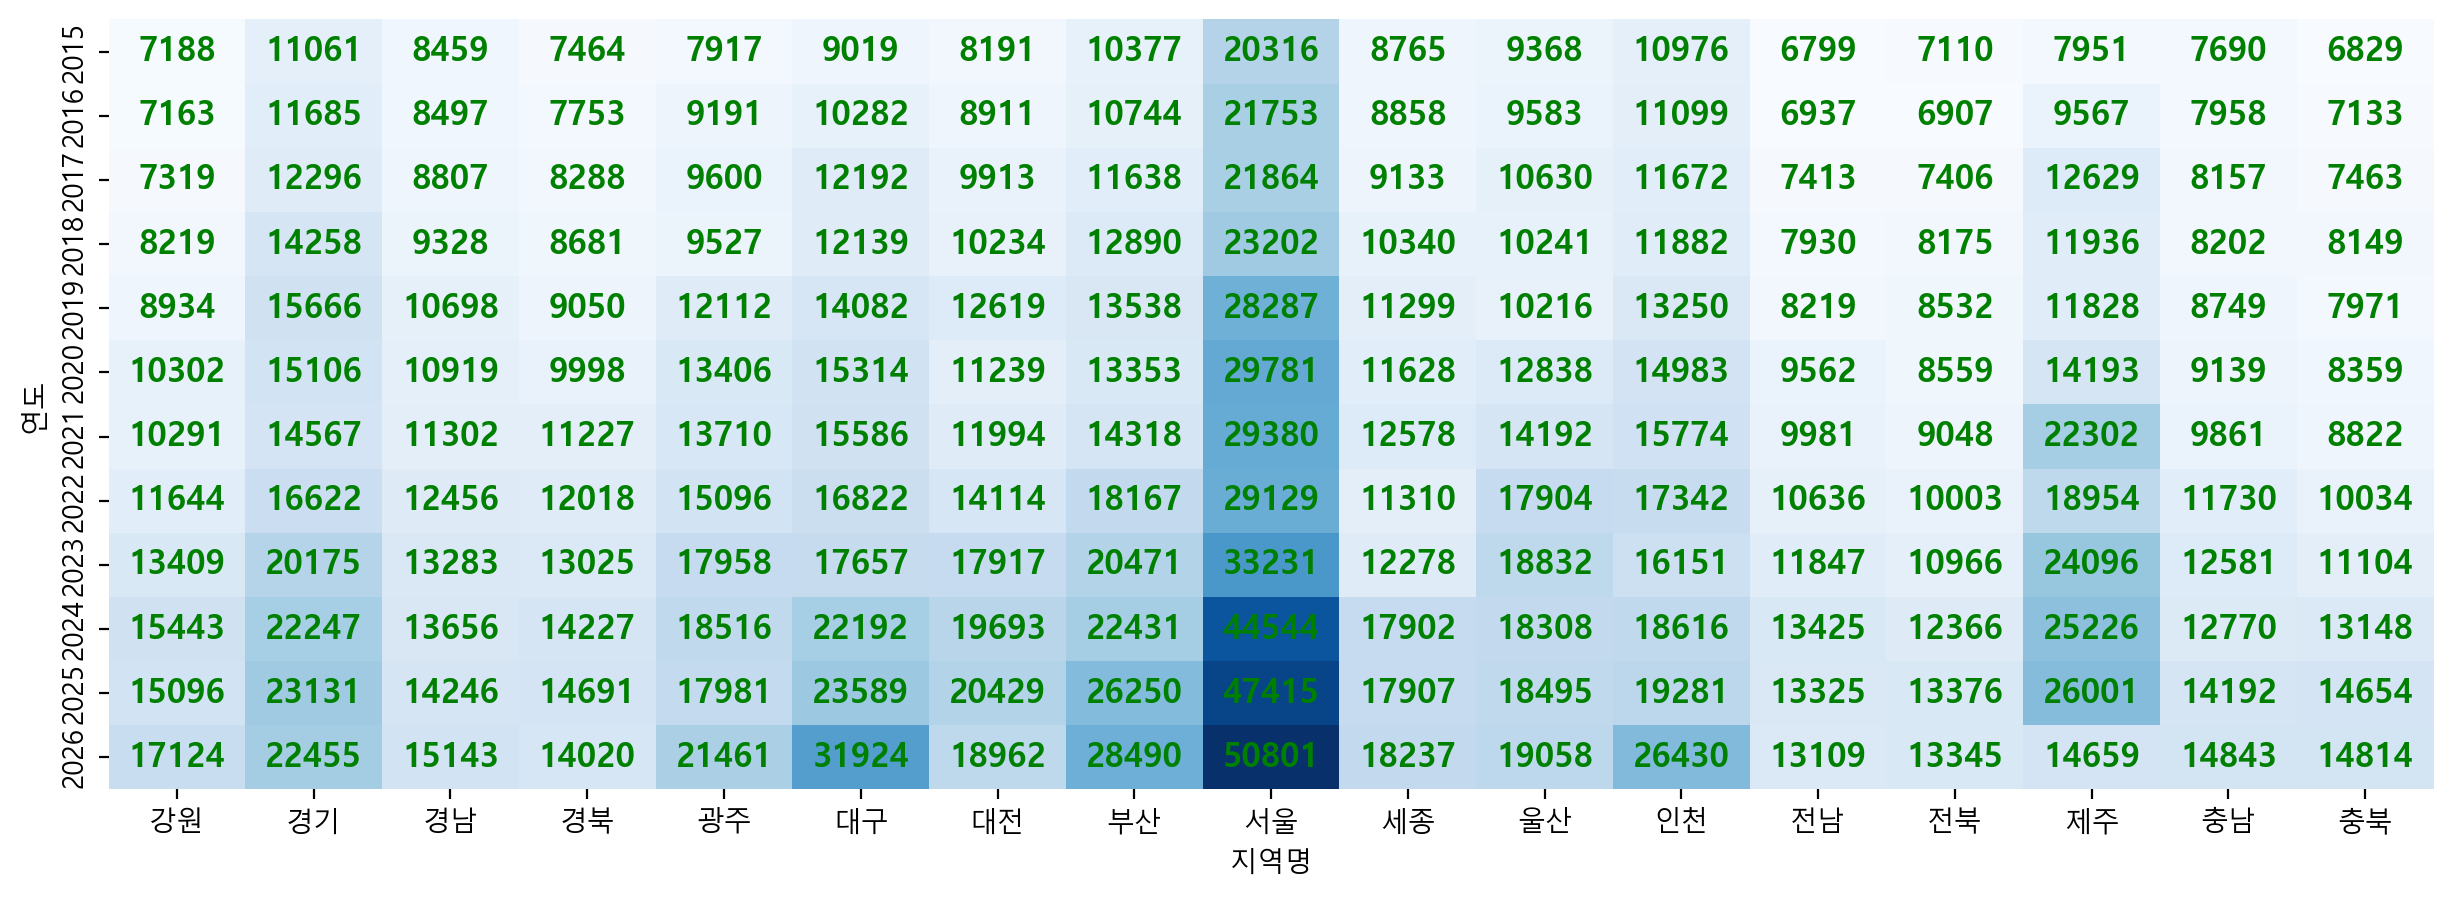

In [298]:
r = df_last.groupby(['연도','지역명'])[['평당분양가격']].mean().unstack()
r.columns = r.columns.droplevel(0)
plt.figure(figsize=(15,5))
sns.heatmap(r,annot=True,fmt='.0f',cmap='Blues',annot_kws={'color':'green','size':12, 'weight':'bold'},cbar=False)

In [294]:
df_last.pivot_table(index='연도',columns='지역명',values='평당분양가격').head()

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.060000,11060.940,8459.220000,7464.160000,7916.700000,9018.900000,8190.600000,10377.400,20315.680,8765.020000,9367.600000,10976.020000,6798.880000,7110.400000,7951.075000,7689.880000,6828.800
2016,7162.903846,11684.970,8496.730000,7753.405000,9190.683333,10282.030000,8910.733333,10743.535,21753.435,8857.805000,9582.574138,11099.055000,6936.600000,6906.625000,9567.480000,7958.225000,7133.335
2017,7318.850000,12296.185,8806.600000,8288.063793,9599.700000,12191.972222,9912.910526,11637.615,21864.095,9132.945763,10630.160870,11672.430000,7413.230000,7406.126316,12628.539623,8157.315517,7462.565
2018,8219.255000,14258.420,9327.670000,8680.776923,9526.953333,12139.252632,10234.106667,12889.965,23202.245,10340.463158,10241.400000,11881.532143,7929.845000,8174.595000,11935.968000,8201.820000,8149.295
2019,8934.475000,15665.540,10697.615789,9050.250000,12111.675000,14081.650000,12619.200000,13537.865,28286.830,11299.394118,10216.250000,13249.775000,8219.275862,8532.260000,11828.469231,8748.840000,7970.875


In [297]:
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지역명     10880 non-null  object 
 1   전용면적    10880 non-null  object 
 2   연도      10880 non-null  int64  
 3   월       10880 non-null  int64  
 4   평당분양가격  9907 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 425.1+ KB


- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

# 8. matplotlib으로 시각화(위의 도표)
https://www.research.autodesk.com/publications/same-stats-different-graphs/
## (1) 지역별 결측치를 제외한 데이터수(line, bar)

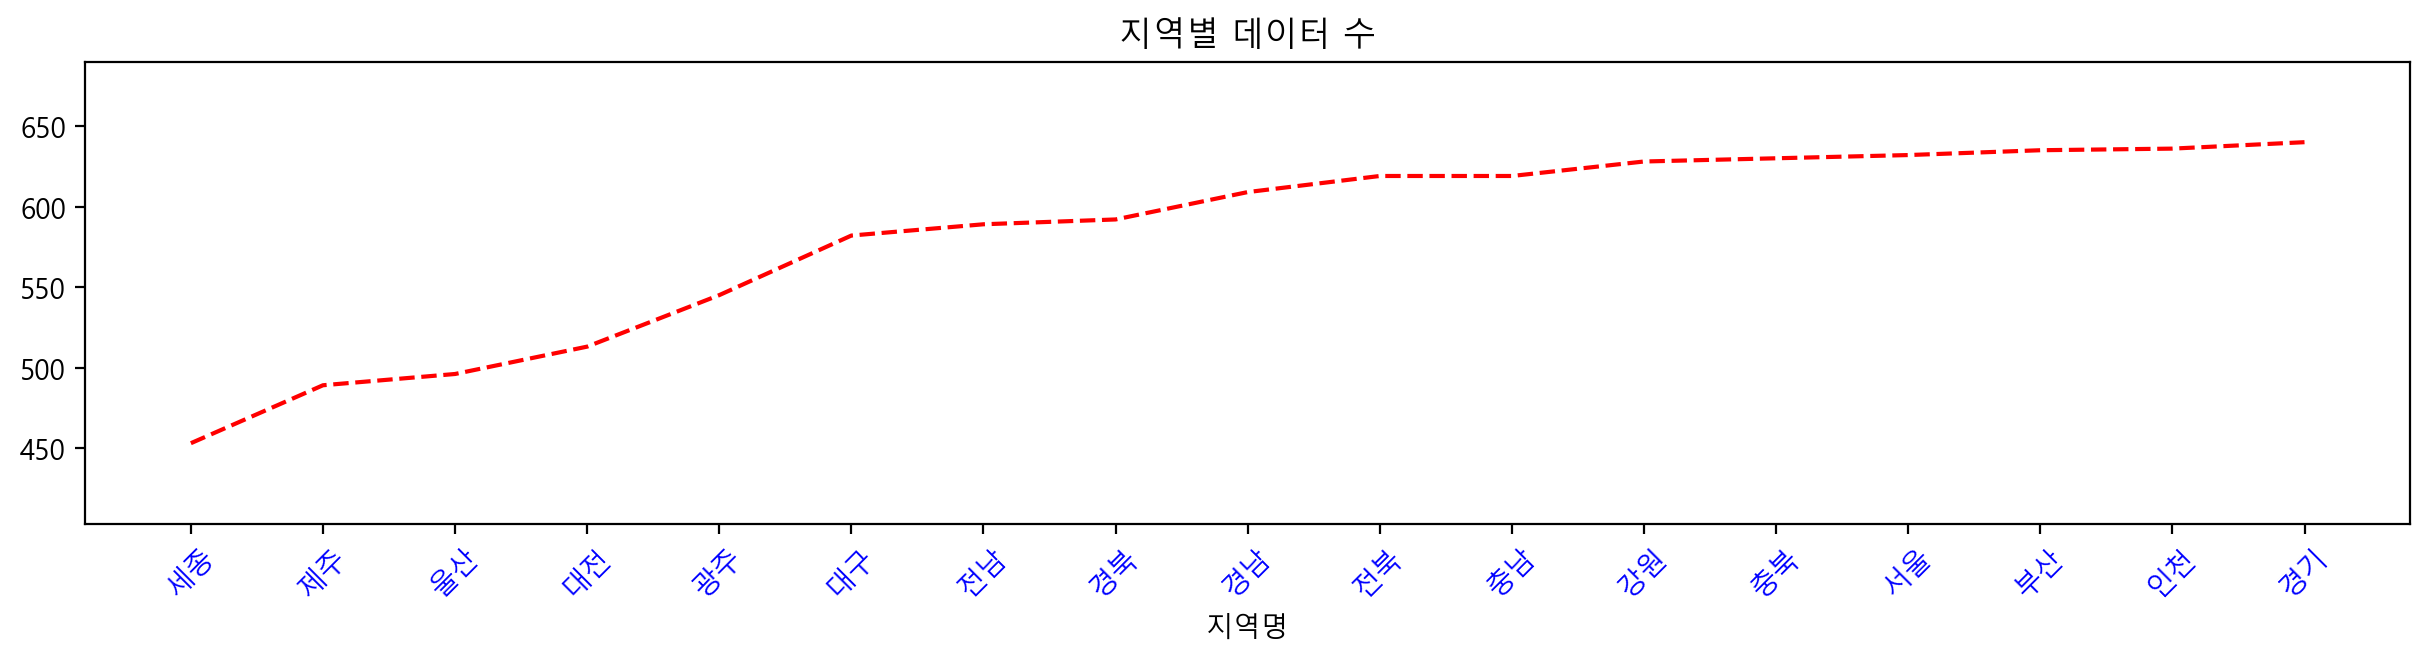

In [323]:
plt.figure(figsize=(15,3))
plt.rcParams['figure.figsize']=(15,3)
result=df_last.groupby('지역명')['평당분양가격'].count().sort_values()
# result.plot.line()
ax=result.plot(kind='line',color='r',linestyle='--',rot=45,
            #ylim=[result.min()-50,result.max()+50],
           title='지역별 데이터 수'
            )
plt.ylim([result.min()-50,result.max()+50])
plt.xticks(range(len(result))) # 축눈금
ax.set_xticklabels(result.index, color='b') #눈금라벨
plt.show() 


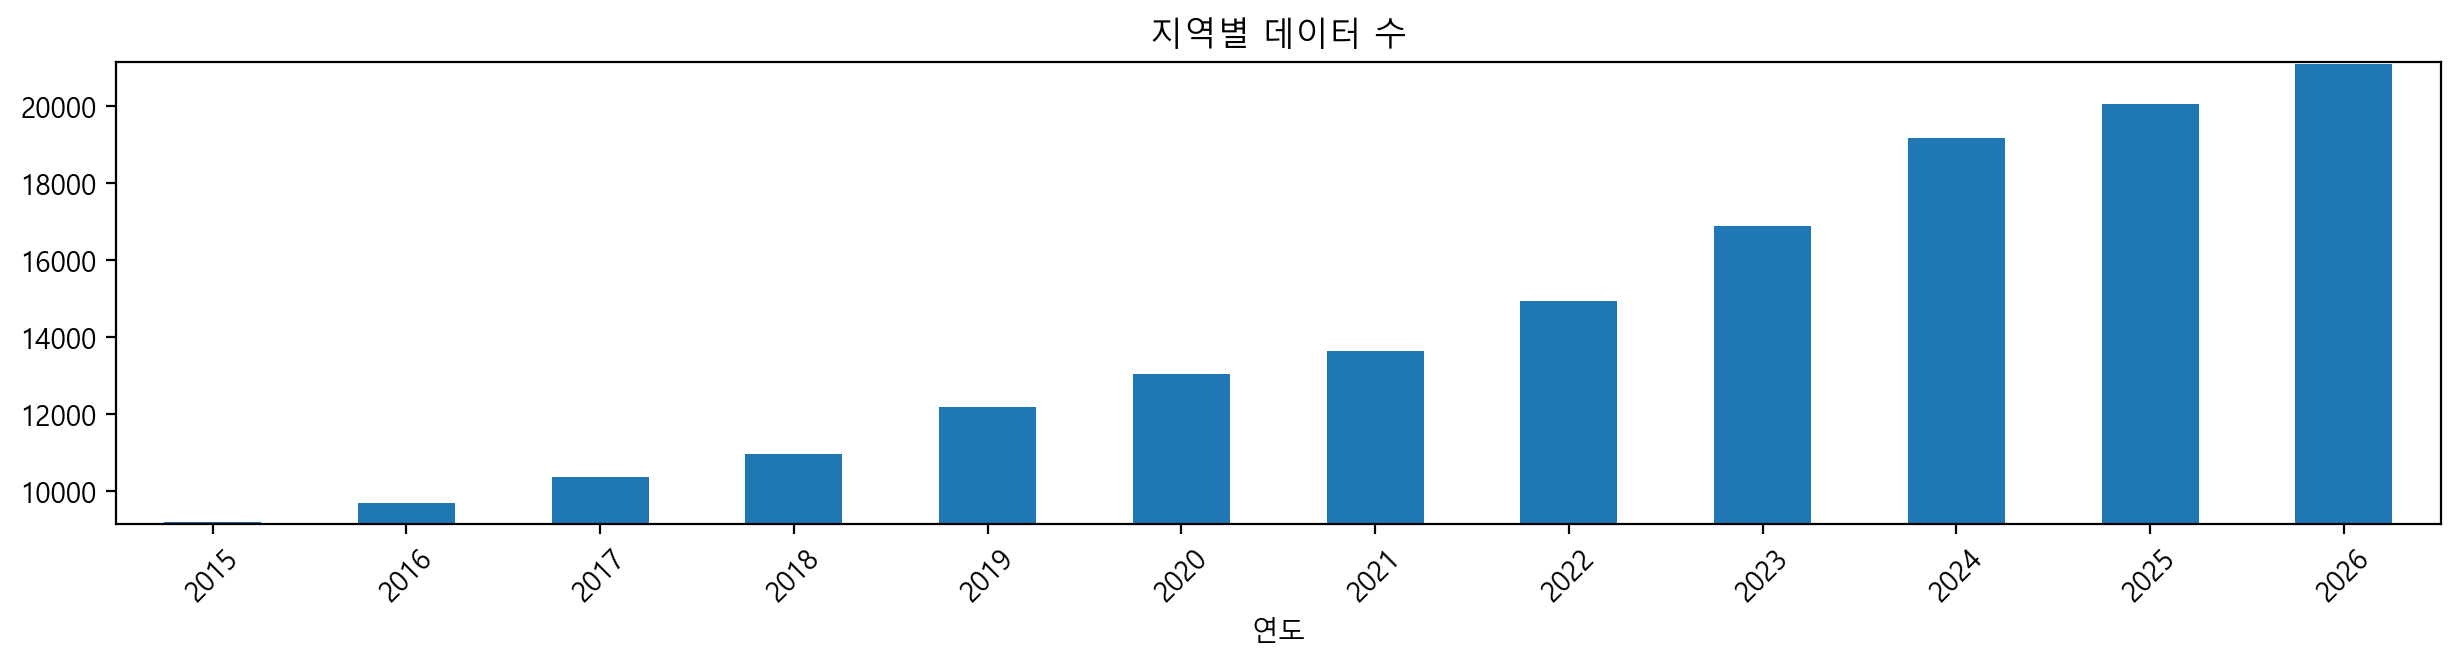

In [399]:
ax = result.plot.bar(rot=45,ylim=[result.min()-50,result.max()+50])
ax.set_title('지역별 데이터 수')
plt.show()

## (2) 지역별 평당분양가격 (line, bar)

<Axes: xlabel='지역명'>

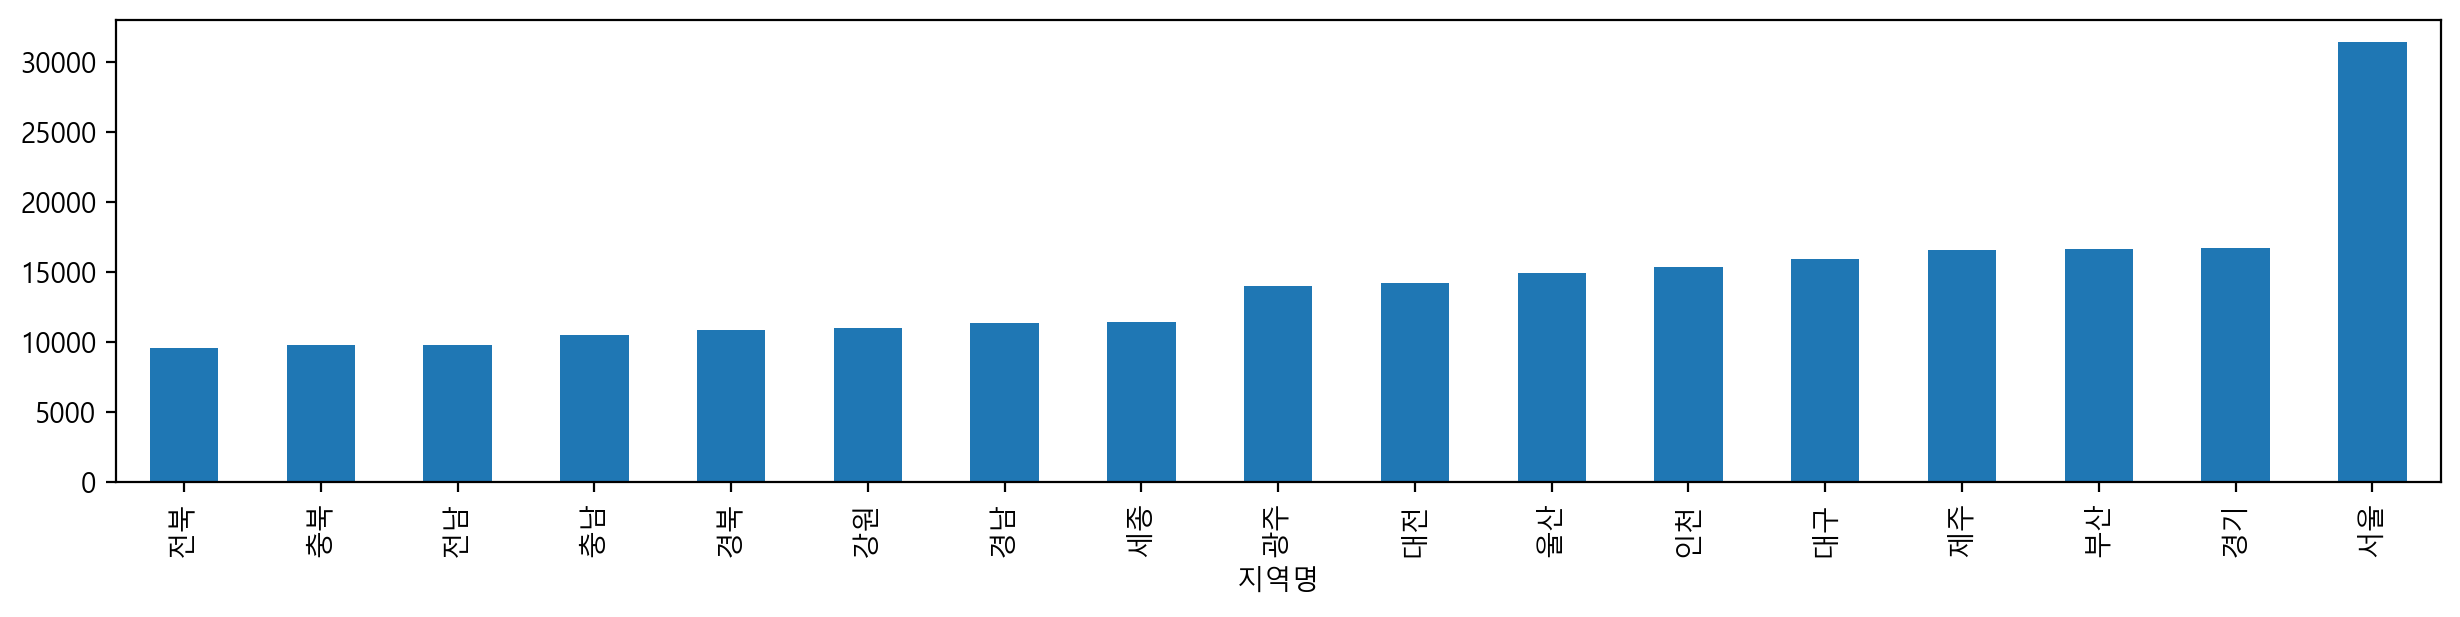

In [341]:
df_last.groupby('지역명')['평당분양가격'].mean().sort_values().plot(kind='bar')

## (3) 전용면적별 평당분양가격(barplot)

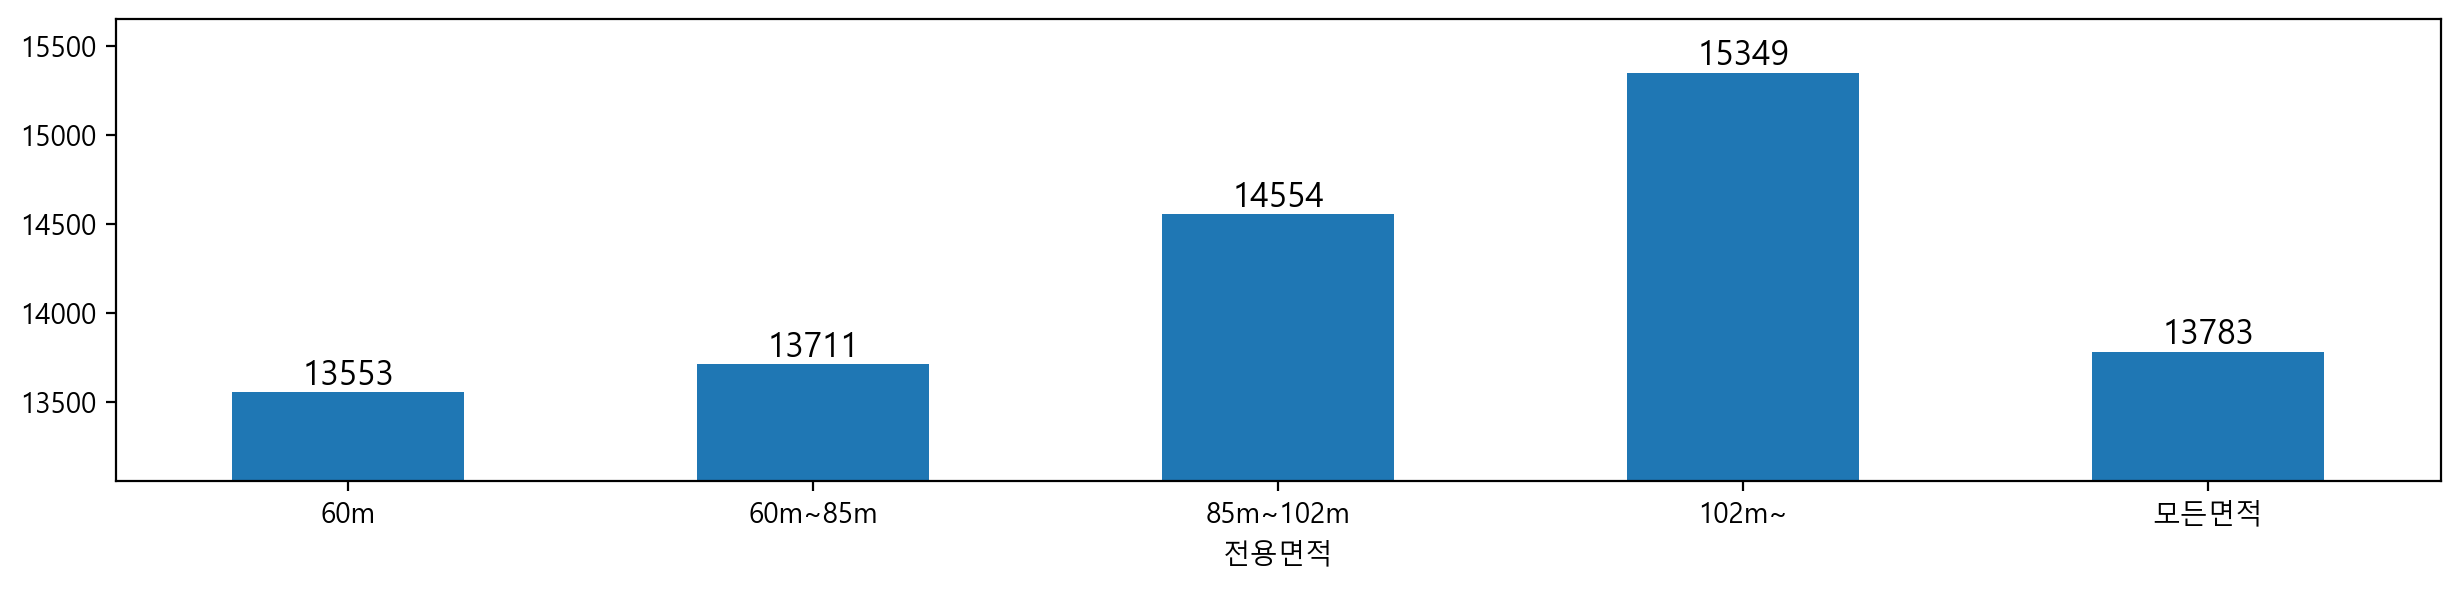

In [378]:
order=['60m','60m~85m','85m~102m','102m~','모든면적']
result = df_last.groupby('전용면적')['평당분양가격'].mean().reindex(order)
result.plot(kind='bar',rot=0,ylim=[result.min()-500,result.max()+300])
for i, val in enumerate(result):
   # plt.text(i-0.1,val+100,round(val),fontsize=15,c='b')
    #va : 수직정렬 , ha : 수평정렬
    plt.text(i,val,round(val),fontsize=12,va='bottom',ha='center')

In [357]:
for i, val in enumerate(result):
    print(i, val)

0 13553.34658976931
1 13710.910107627515
2 14554.491726618704
3 15348.875444839858
4 13783.366324147595


## (4) 연도별 평균 평당분양가격(line)

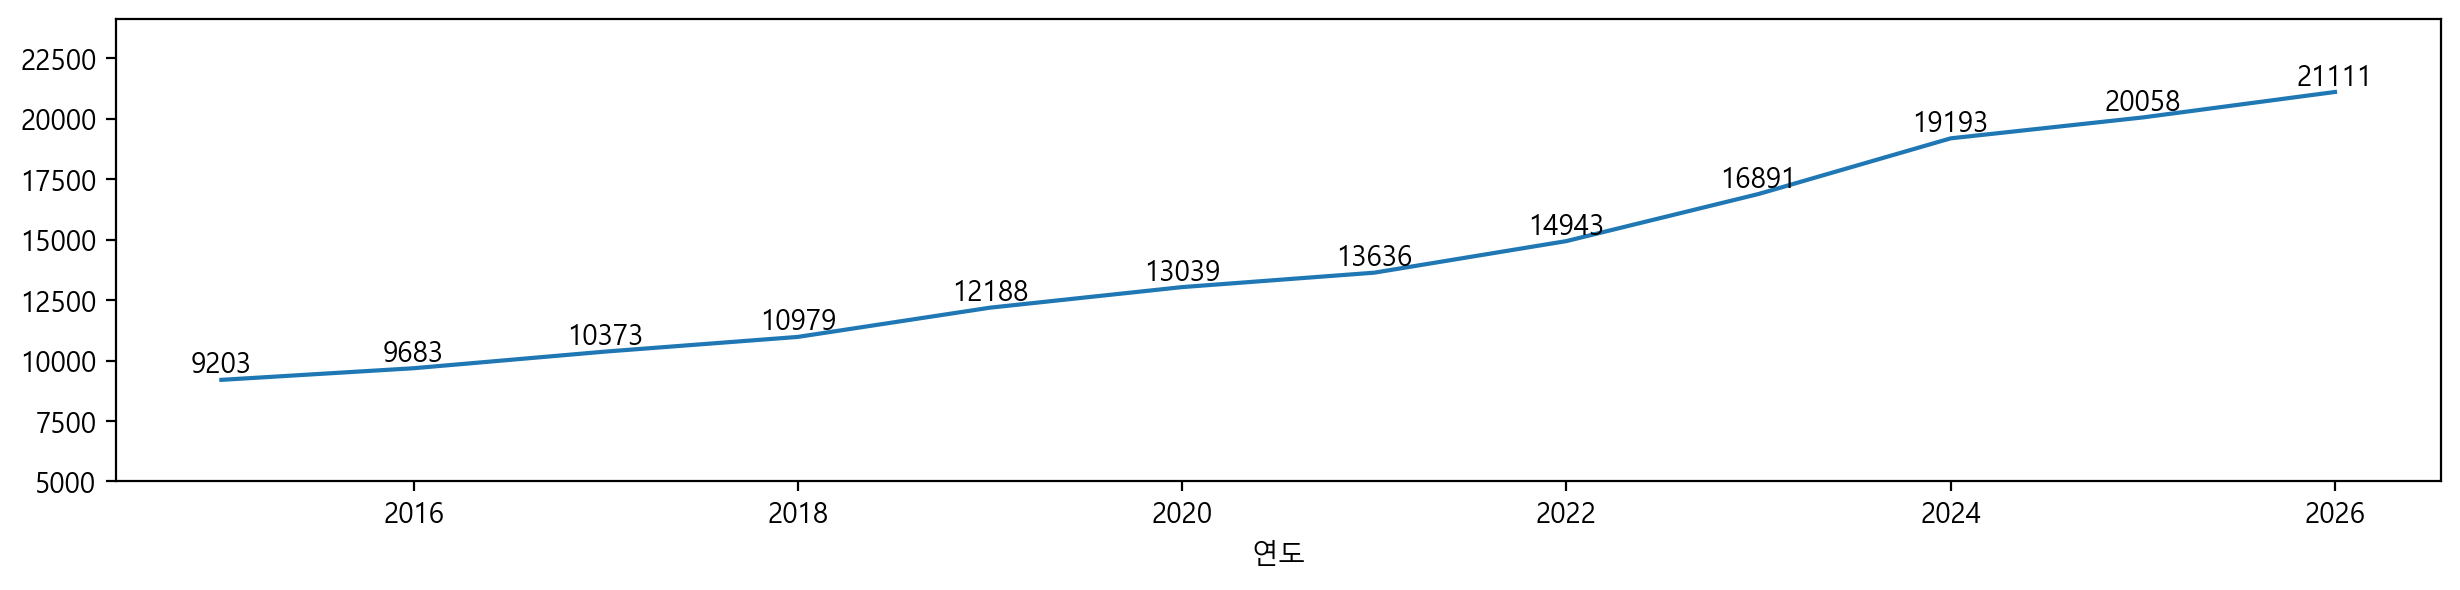

In [384]:
result=df_last.groupby('연도')['평당분양가격'].mean()
result.plot(kind='line',ylim=[5000,result.max()+3000])
for year, val in result.items():
    plt.text(year,val,round(val),va='bottom',ha='center')
    

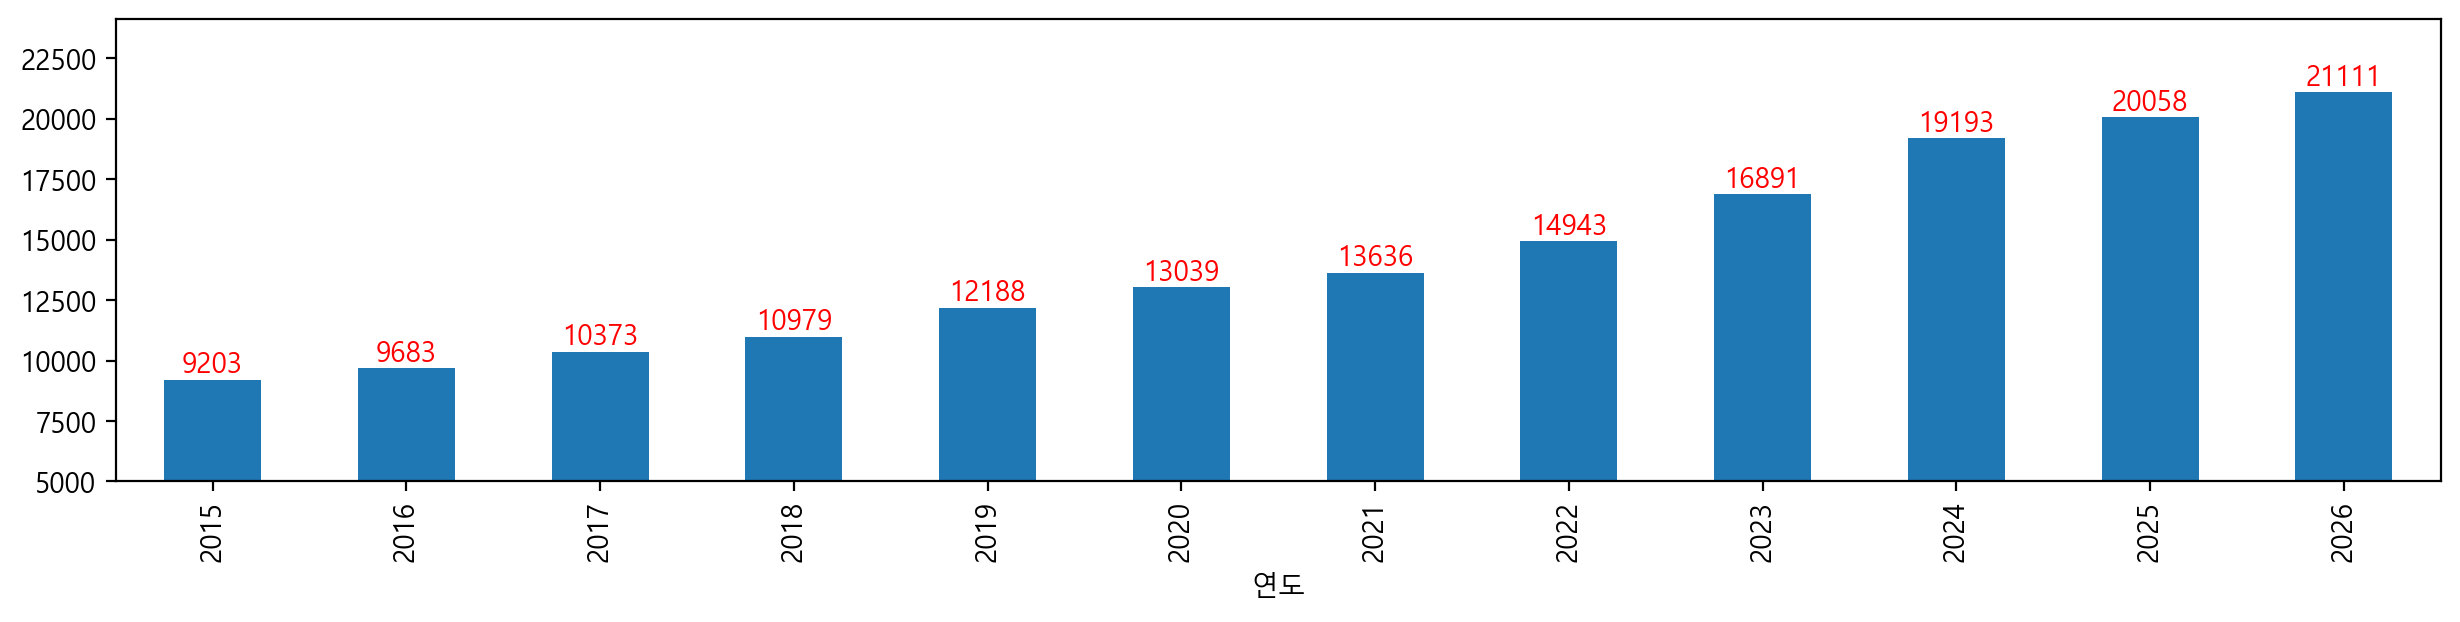

In [388]:
result=df_last.groupby('연도')['평당분양가격'].mean()
result.plot(kind='bar',ylim=[5000,result.max()+3000])
for i, val in enumerate(result):
    plt.text(i,val,round(val),va='bottom',ha='center',color='r')

범례:https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

# 9. seaborn으로 시각화
- 위에서 시각화한 내용을 seaborn으로 시각화

In [ ]:
sns.set(style='white', rc={'figure.figsize':(9,3)})
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

## (1) 지역별 평당분양가격

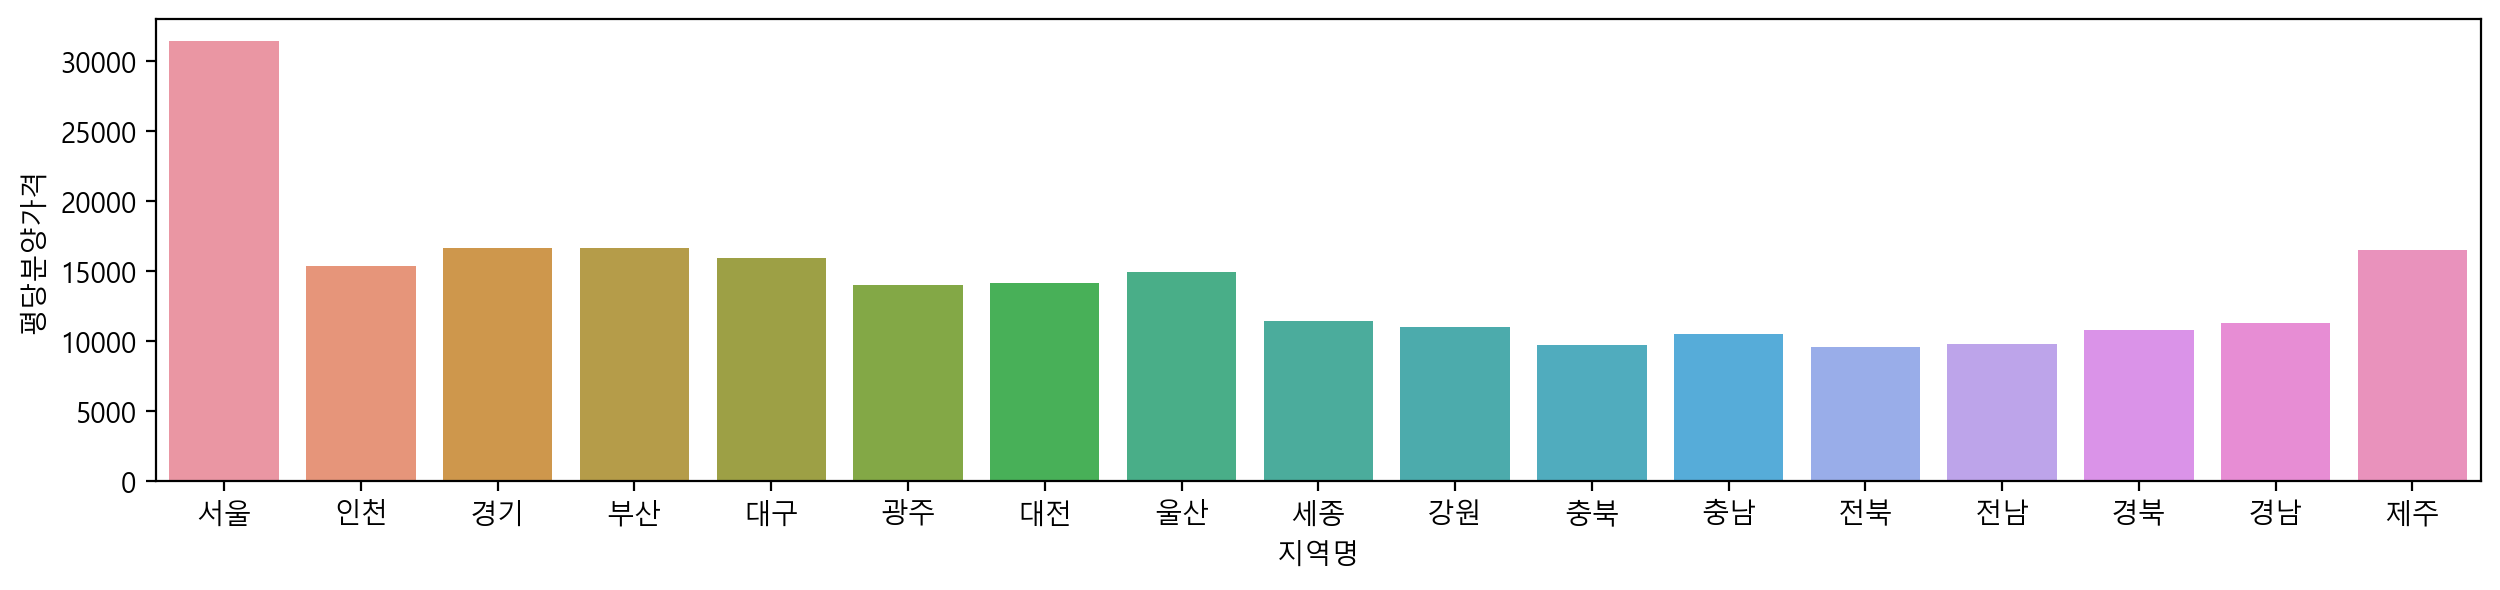

In [401]:
sns.barplot(data=df_last,x='지역명',y='평당분양가격',errorbar=None)
plt.show()

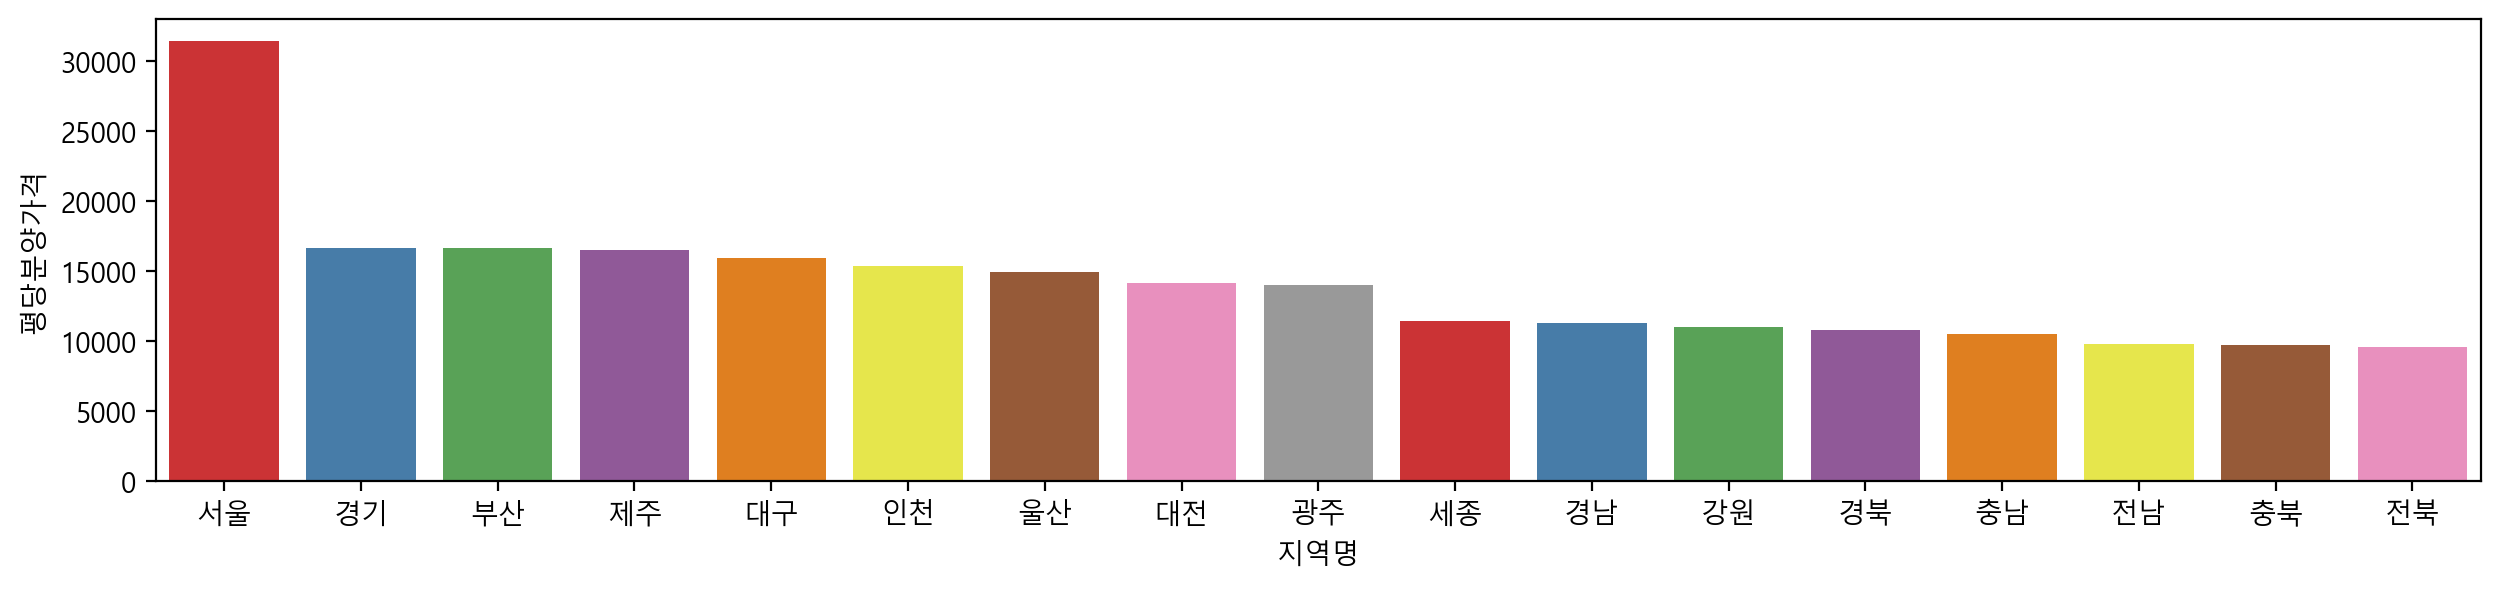

In [406]:
result=df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)
sns.barplot(data=df_last,x='지역명',y='평당분양가격',errorbar=None,order=result.index, palette='Set1')
plt.show()

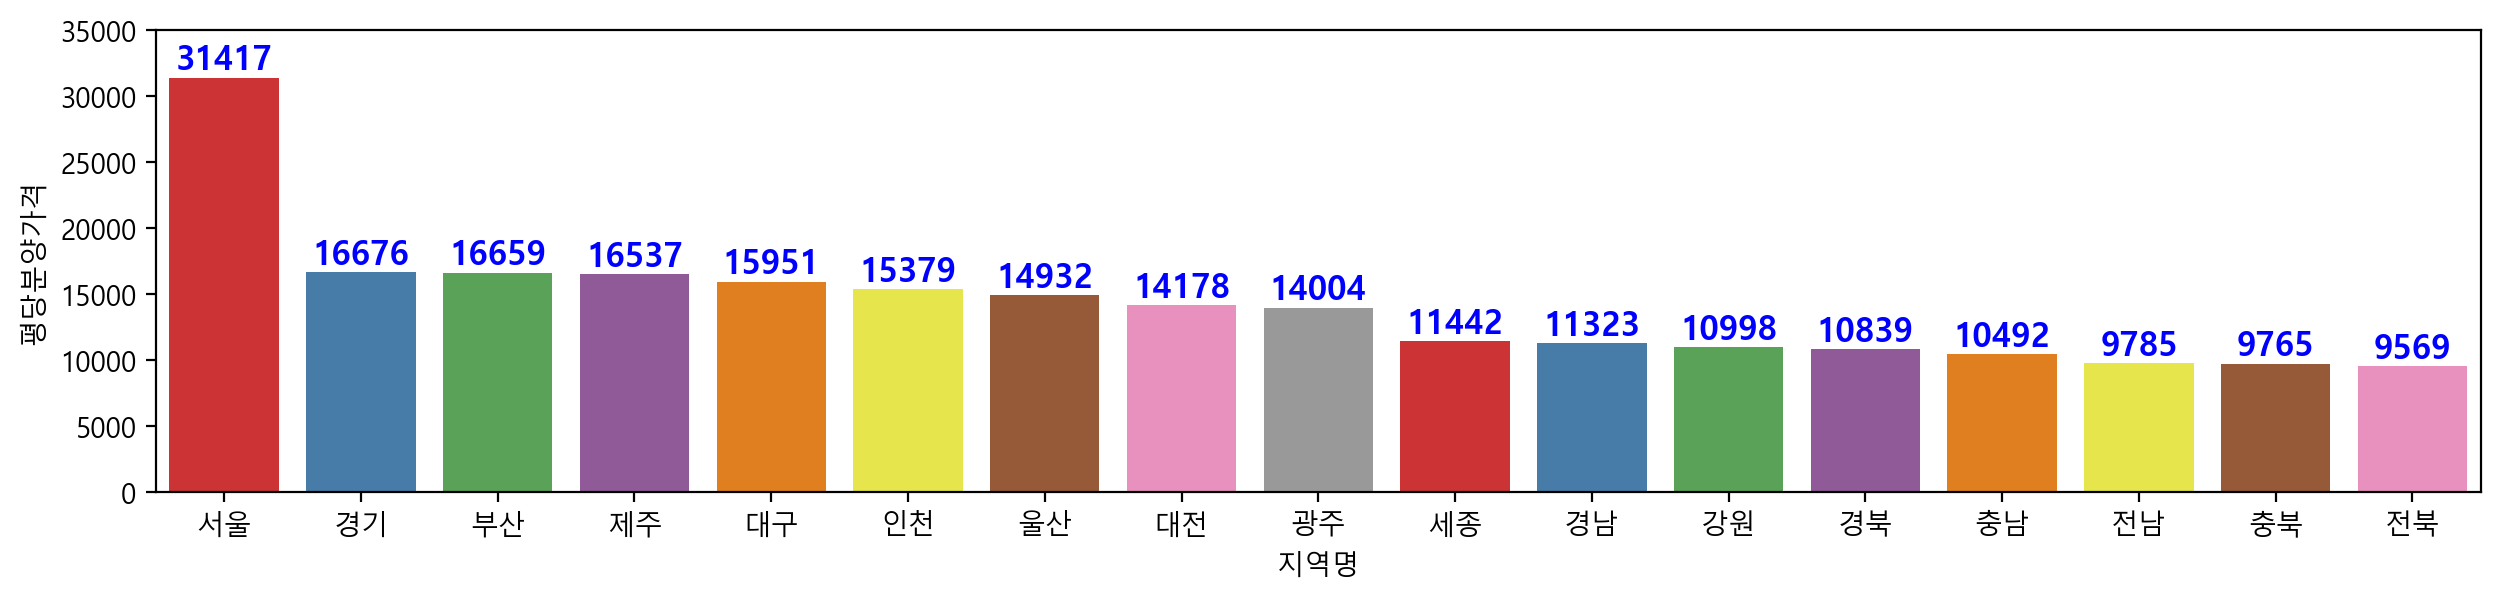

In [415]:
result=df_last.groupby('지역명')['평당분양가격'].mean().sort_values(ascending=False)  
sns.barplot(data=df_last,x='지역명',y='평당분양가격',errorbar=None,order=result.index, palette='Set1')
plt.ylim([0,35000])
for i, v in enumerate(result):
    plt.text(i,v,round(v),va='bottom',ha='center',fontsize=12,color='b',weight='bold')

## (2) 연도별 평당분양가격

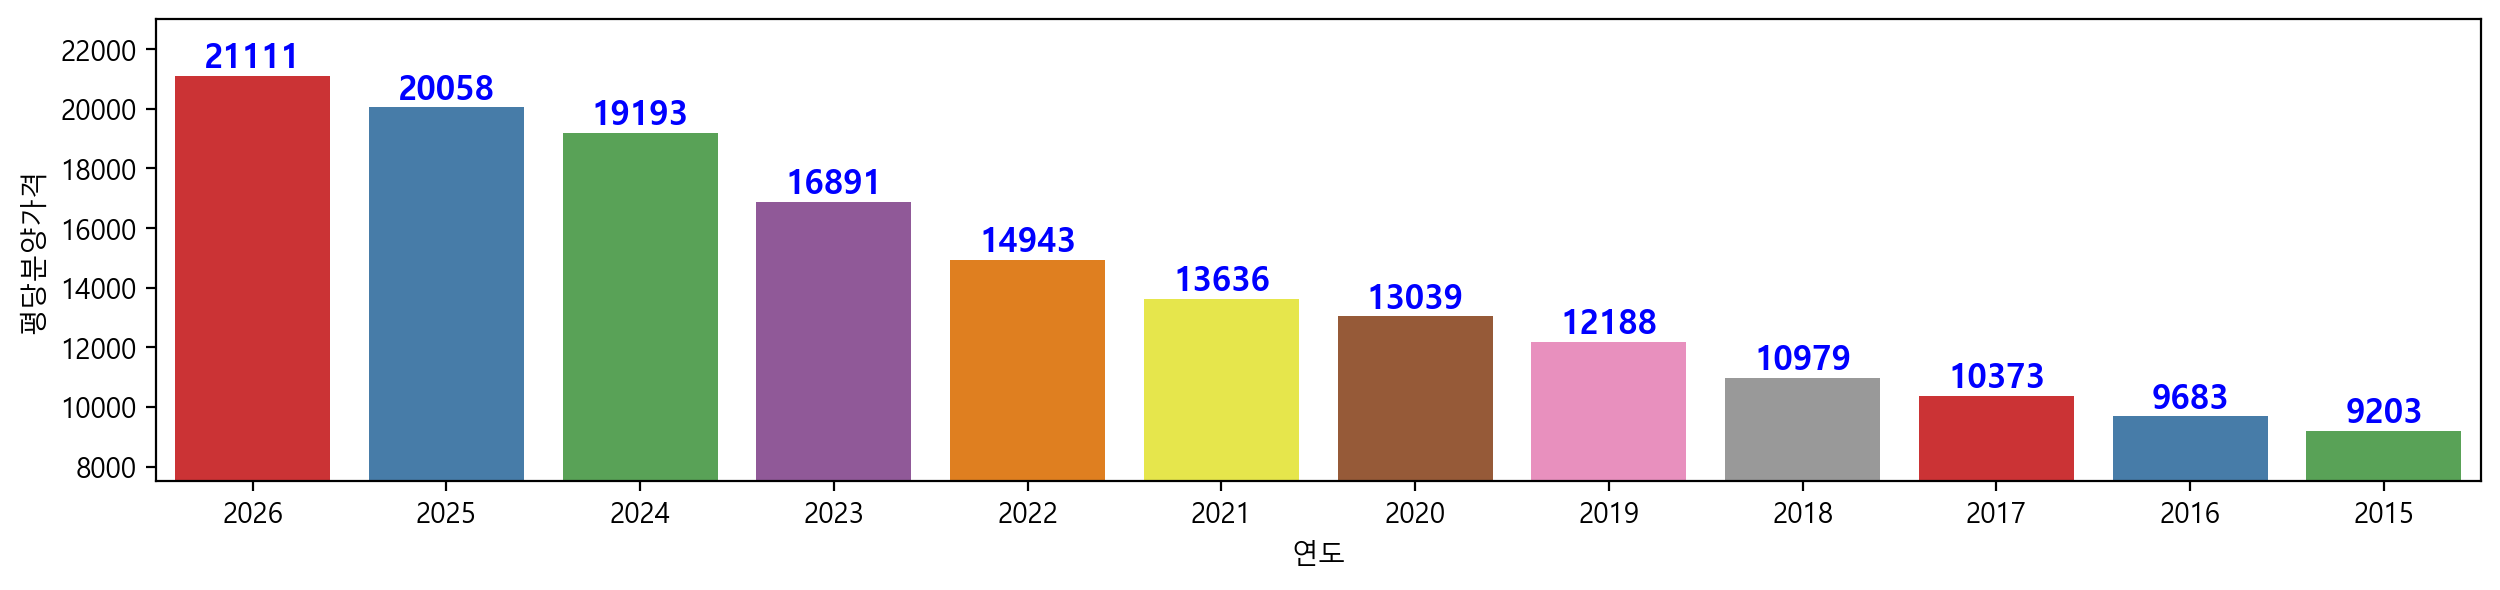

In [425]:
result=df_last.groupby('연도')['평당분양가격'].mean().sort_values(ascending=False) 
sns.barplot(data=df_last,x='연도',y='평당분양가격',errorbar=None,order=result.index, palette='Set1')
plt.ylim([7500,23000])
for i, v in enumerate(result):
    plt.text(i,v,round(v),va='bottom',ha='center',fontsize=12,color='b',weight='bold')

## (3) 그 외 lineplot, relplot, boxplot, violinplot, boxexplot, regplot, swarmplot

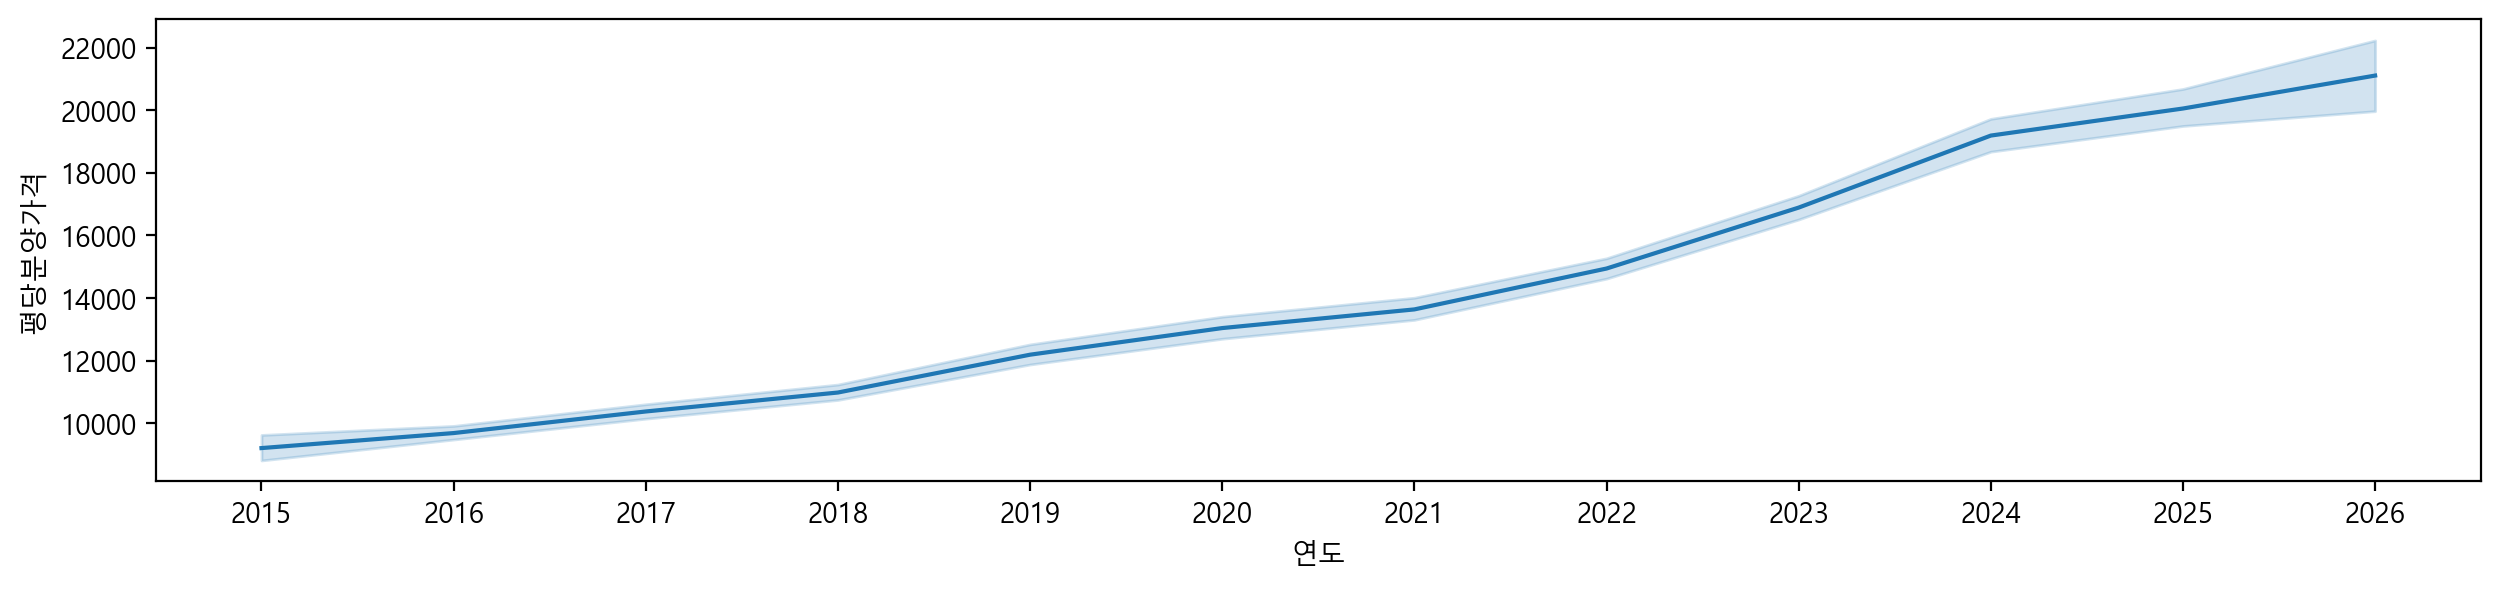

In [427]:
#년도별 평균 분양가격 추이
sns.lineplot(data=df_last,x='연도',y='평당분양가격')
plt.xticks(range(2015,2027))
plt.show()

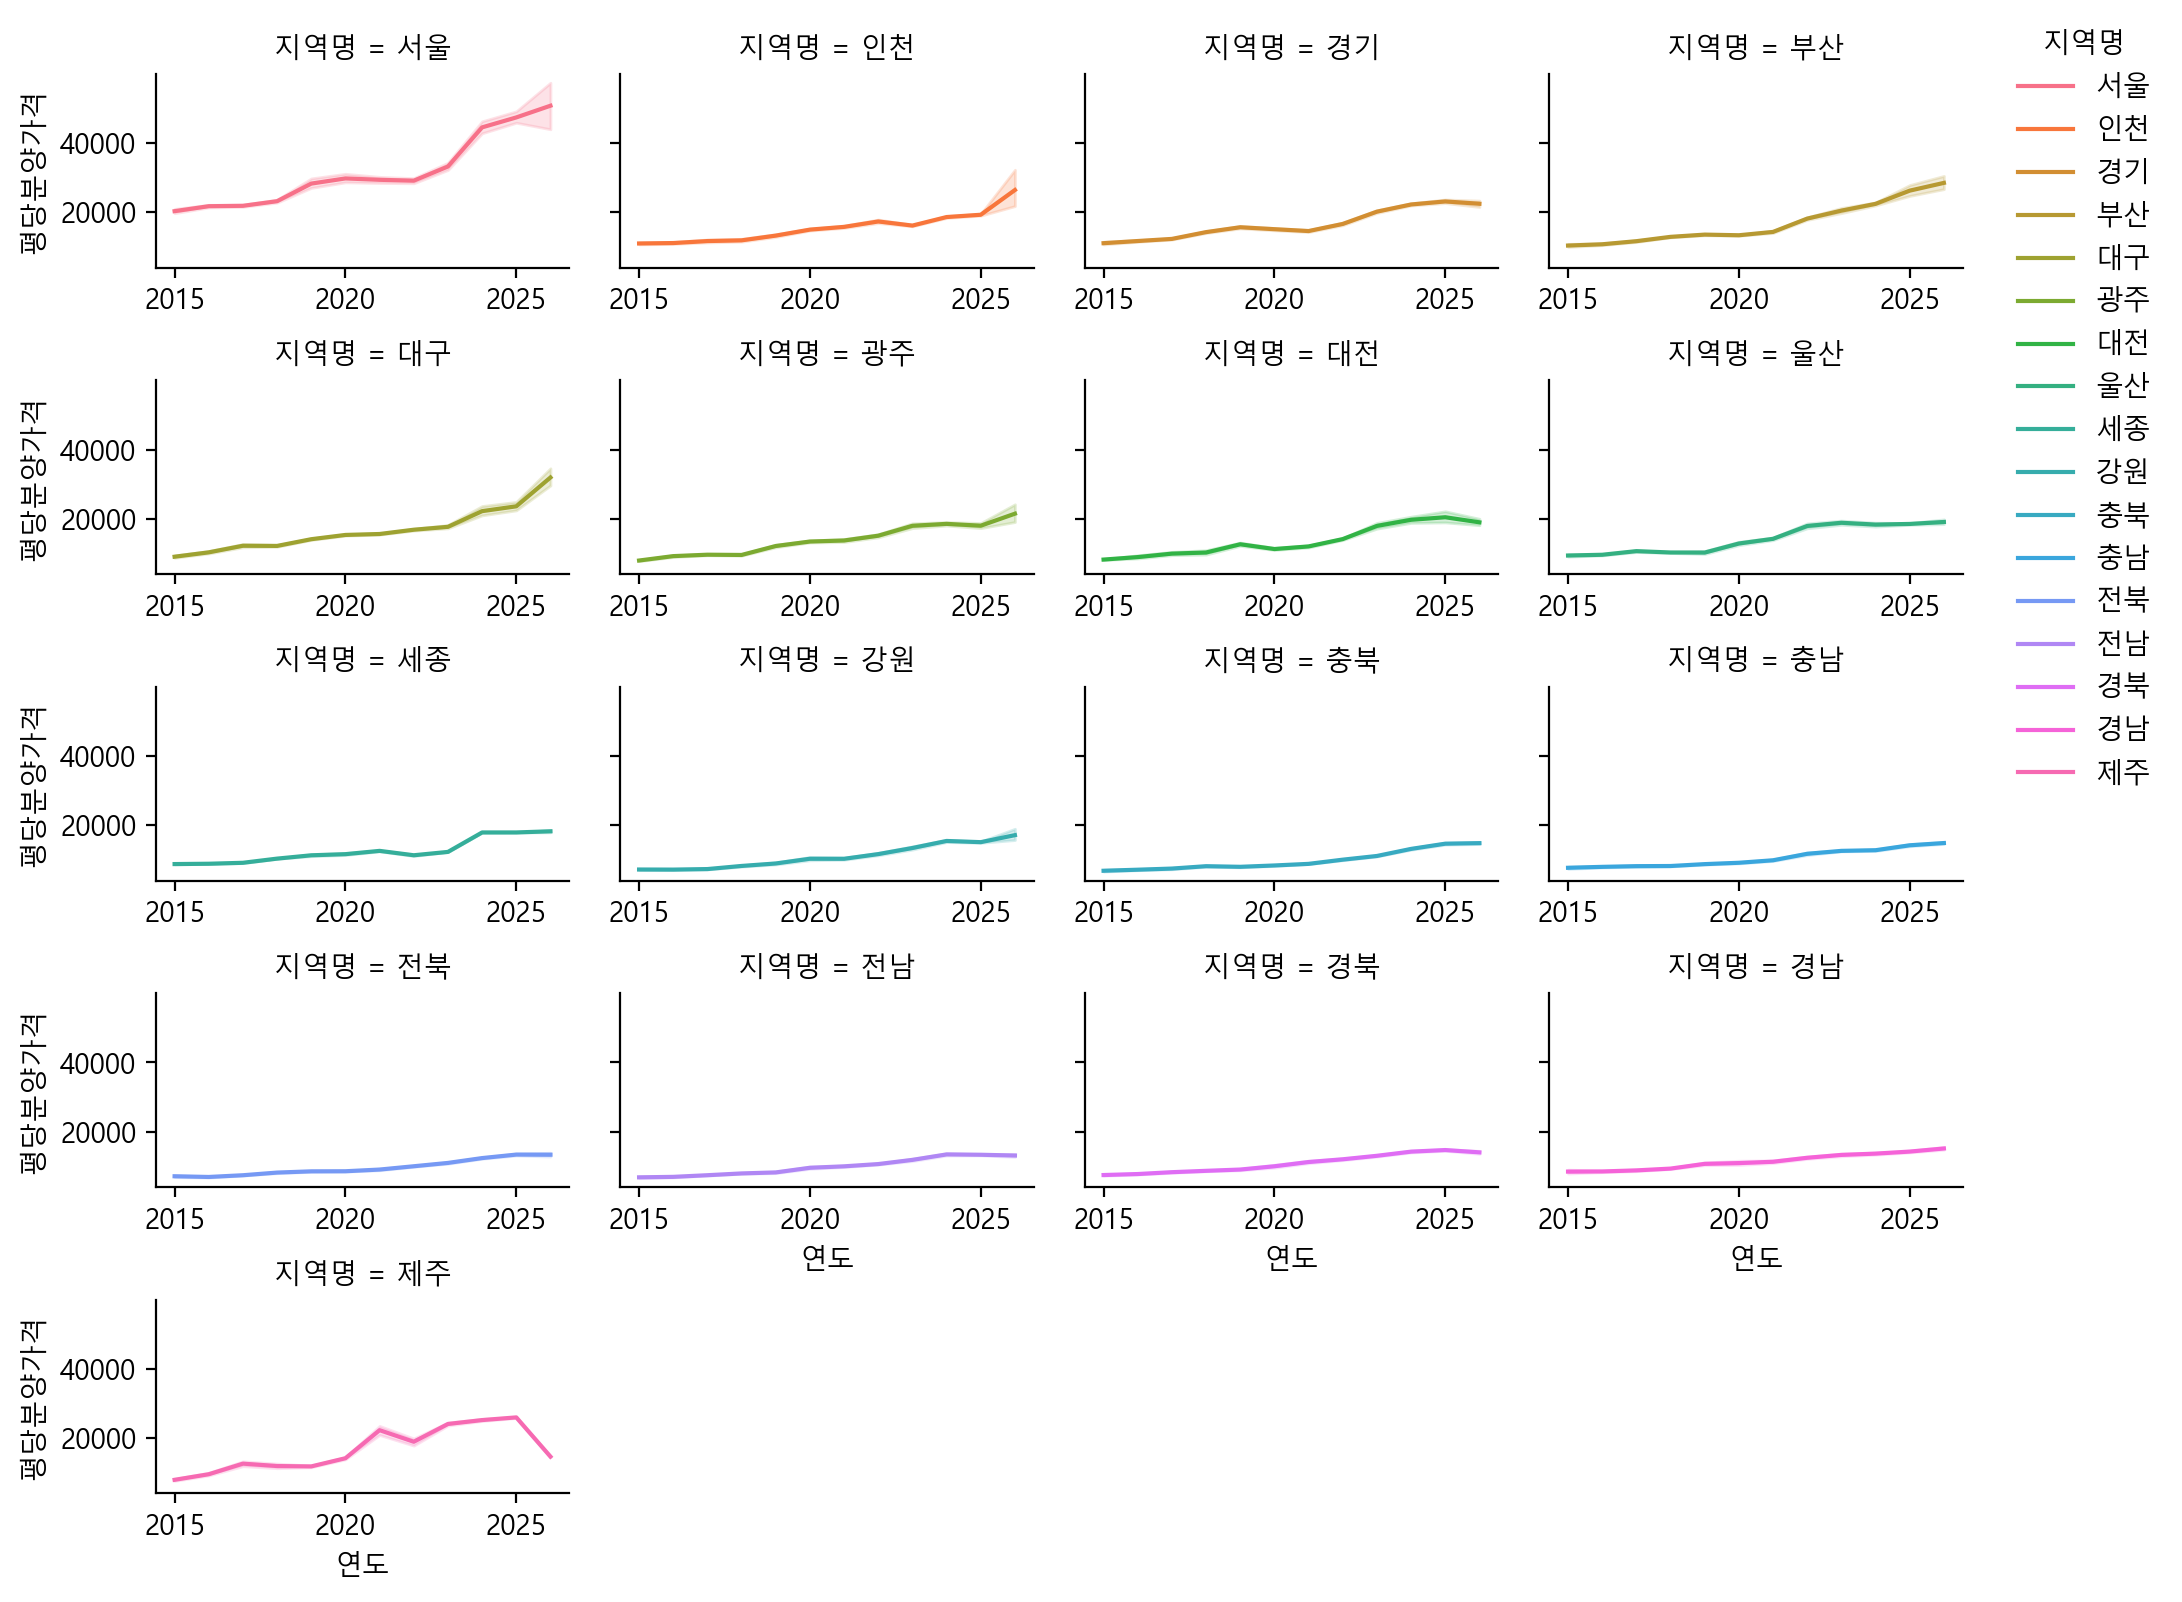

In [438]:
#년도별, 지역별 평당분양가격을 지역별로 서브플롯(relplot)
g= sns.relplot(data=df_last,
               x='연도',
              y='평당분양가격',kind='line',hue='지역명',col='지역명',
              col_wrap=4, facet_kws={'sharex':False, 'sharex':False})
g.fig.set_size_inches(10,8)
plt.tight_layout()
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))

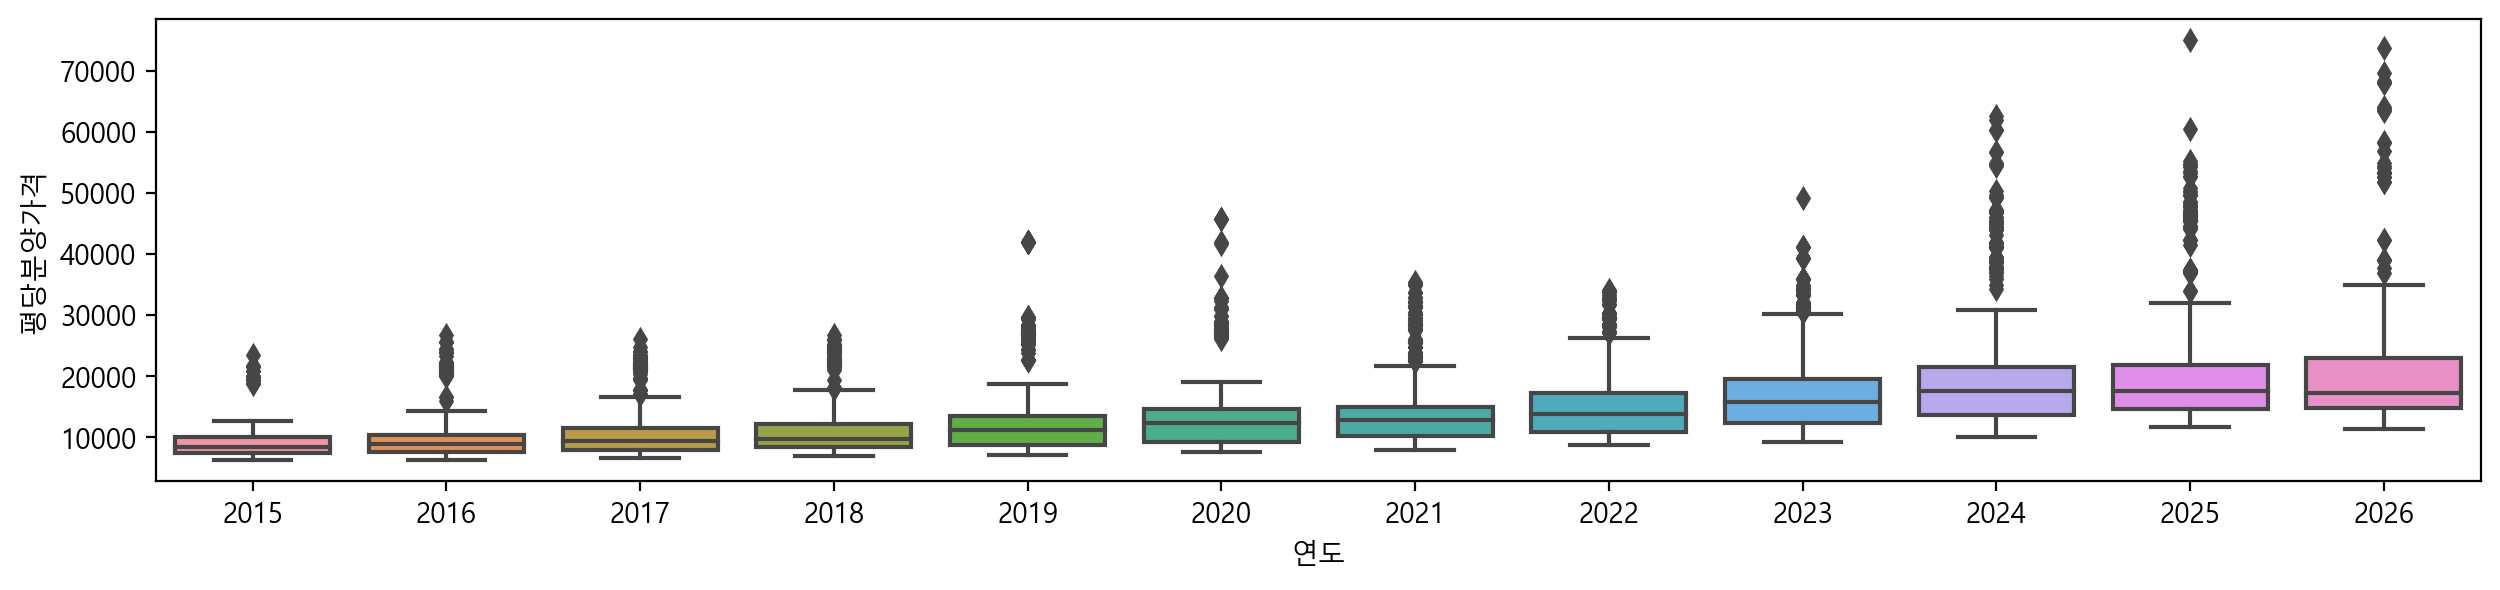

In [441]:
# 연도별 평당분양가격의 boxplot, violinplot, boxenplot
sns.boxplot(data=df_last, x='연도',y='평당분양가격')
plt.show()

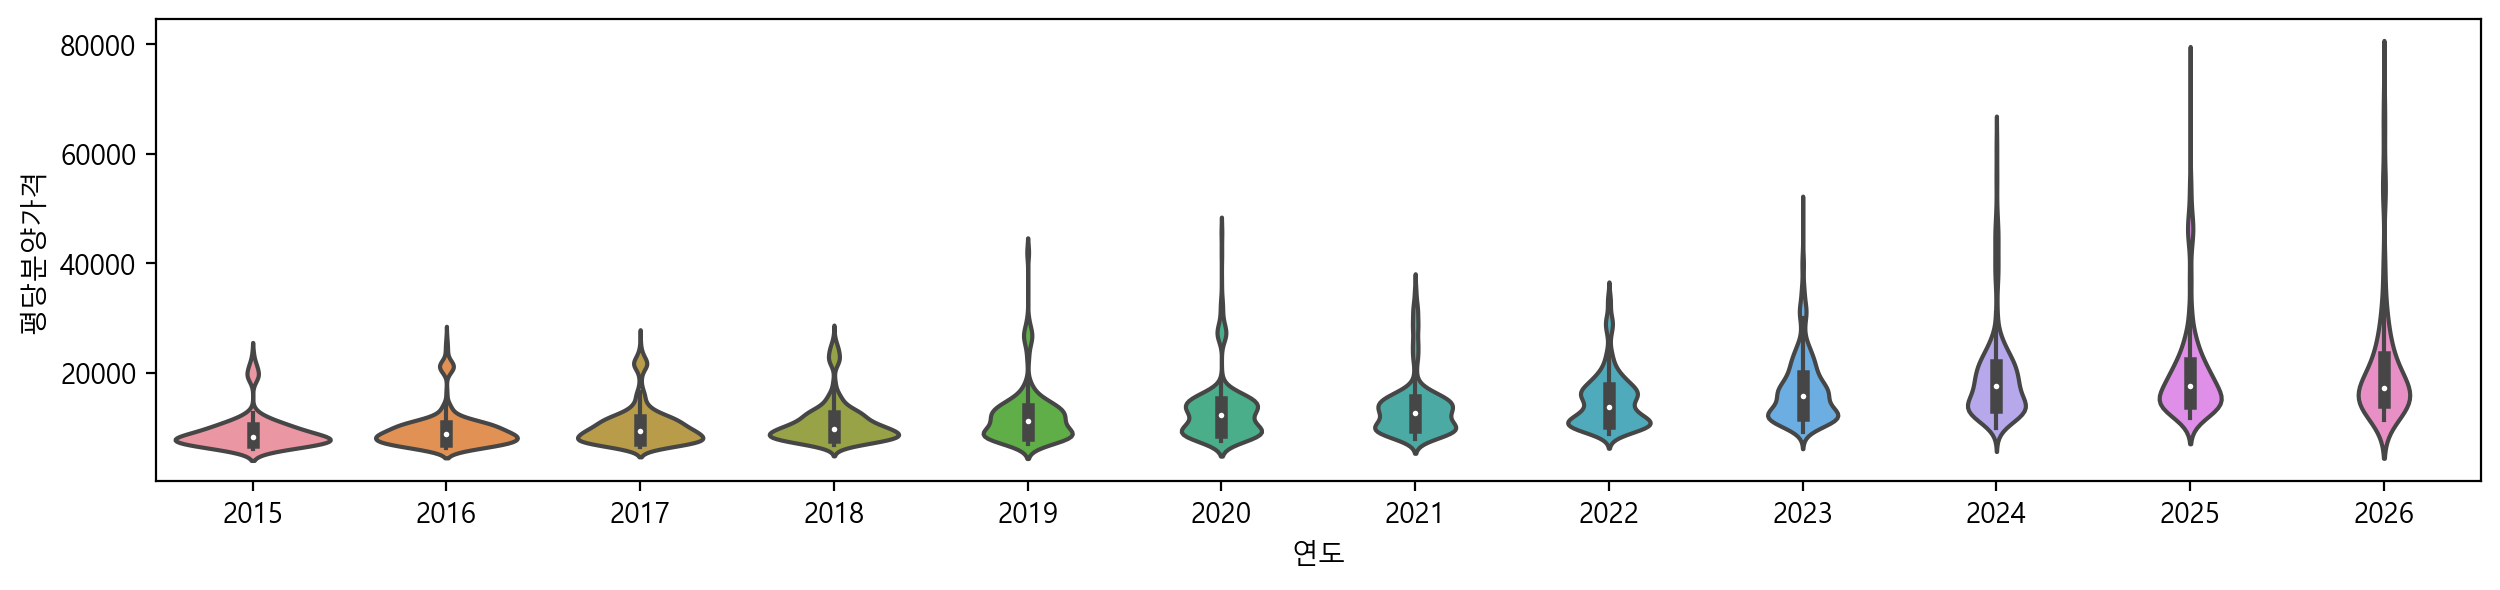

In [442]:
sns.violinplot(data=df_last, x='연도',y='평당분양가격')
plt.show()

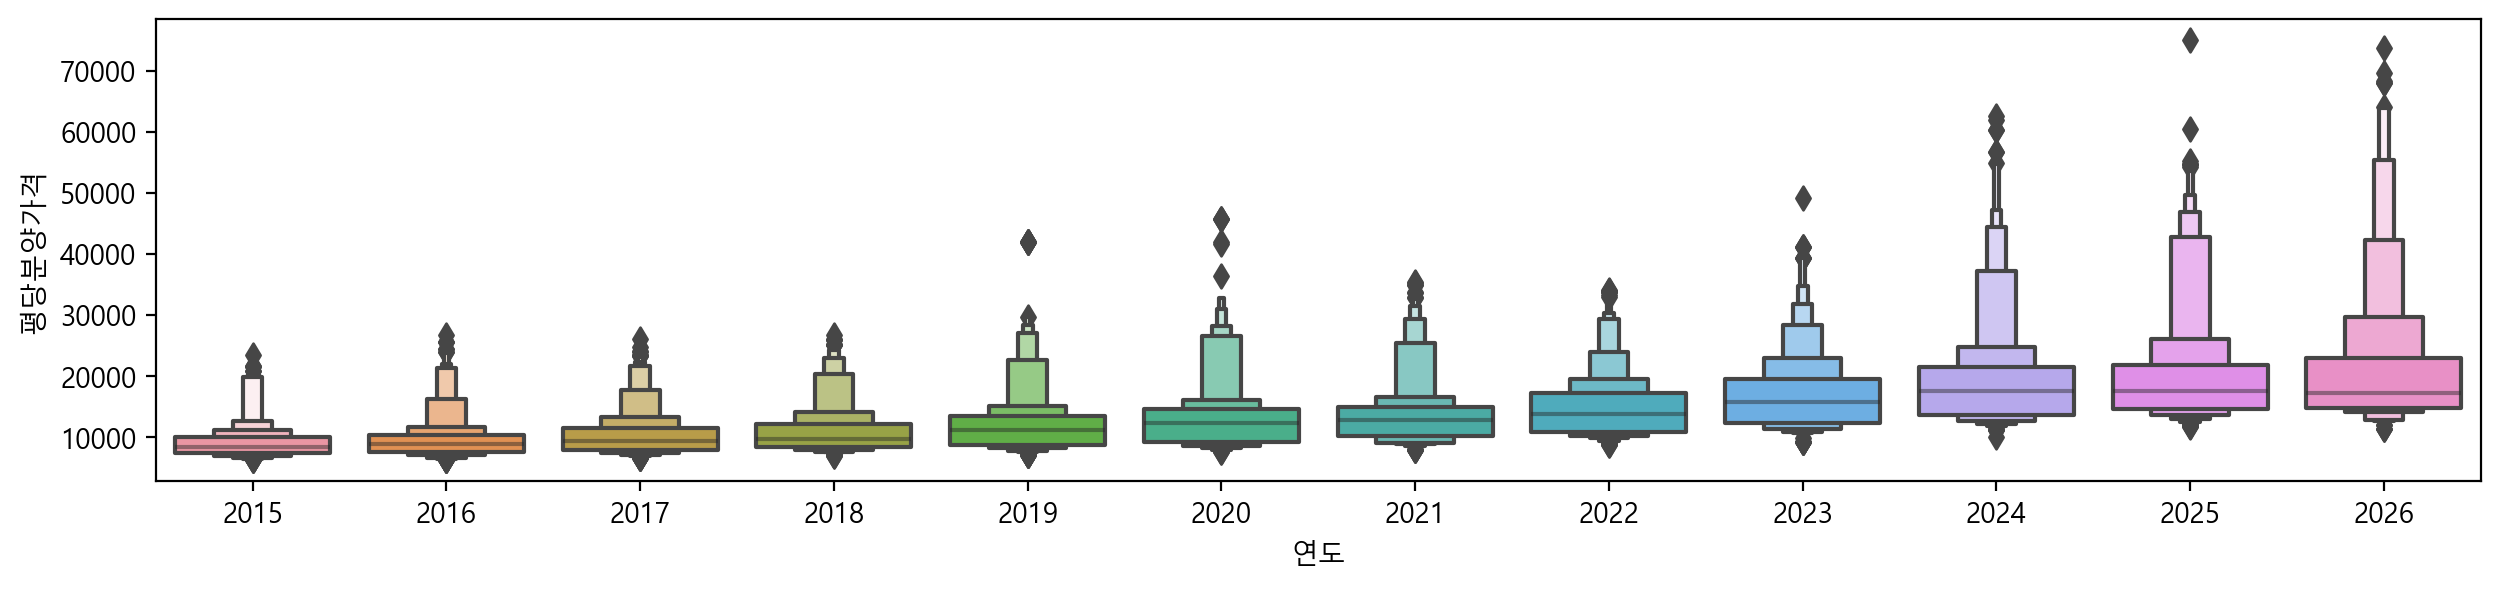

In [443]:
sns.boxenplot(data=df_last, x='연도',y='평당분양가격')
plt.show()

In [444]:
%%time
#연도별 평당분양가격 산점도
#sns.swarmplot(data=df_last, x='연도', y='평당분양가격', size=3)
#plt.show()

CPU times: total: 0 ns
Wall time: 0 ns


CPU times: total: 359 ms
Wall time: 368 ms


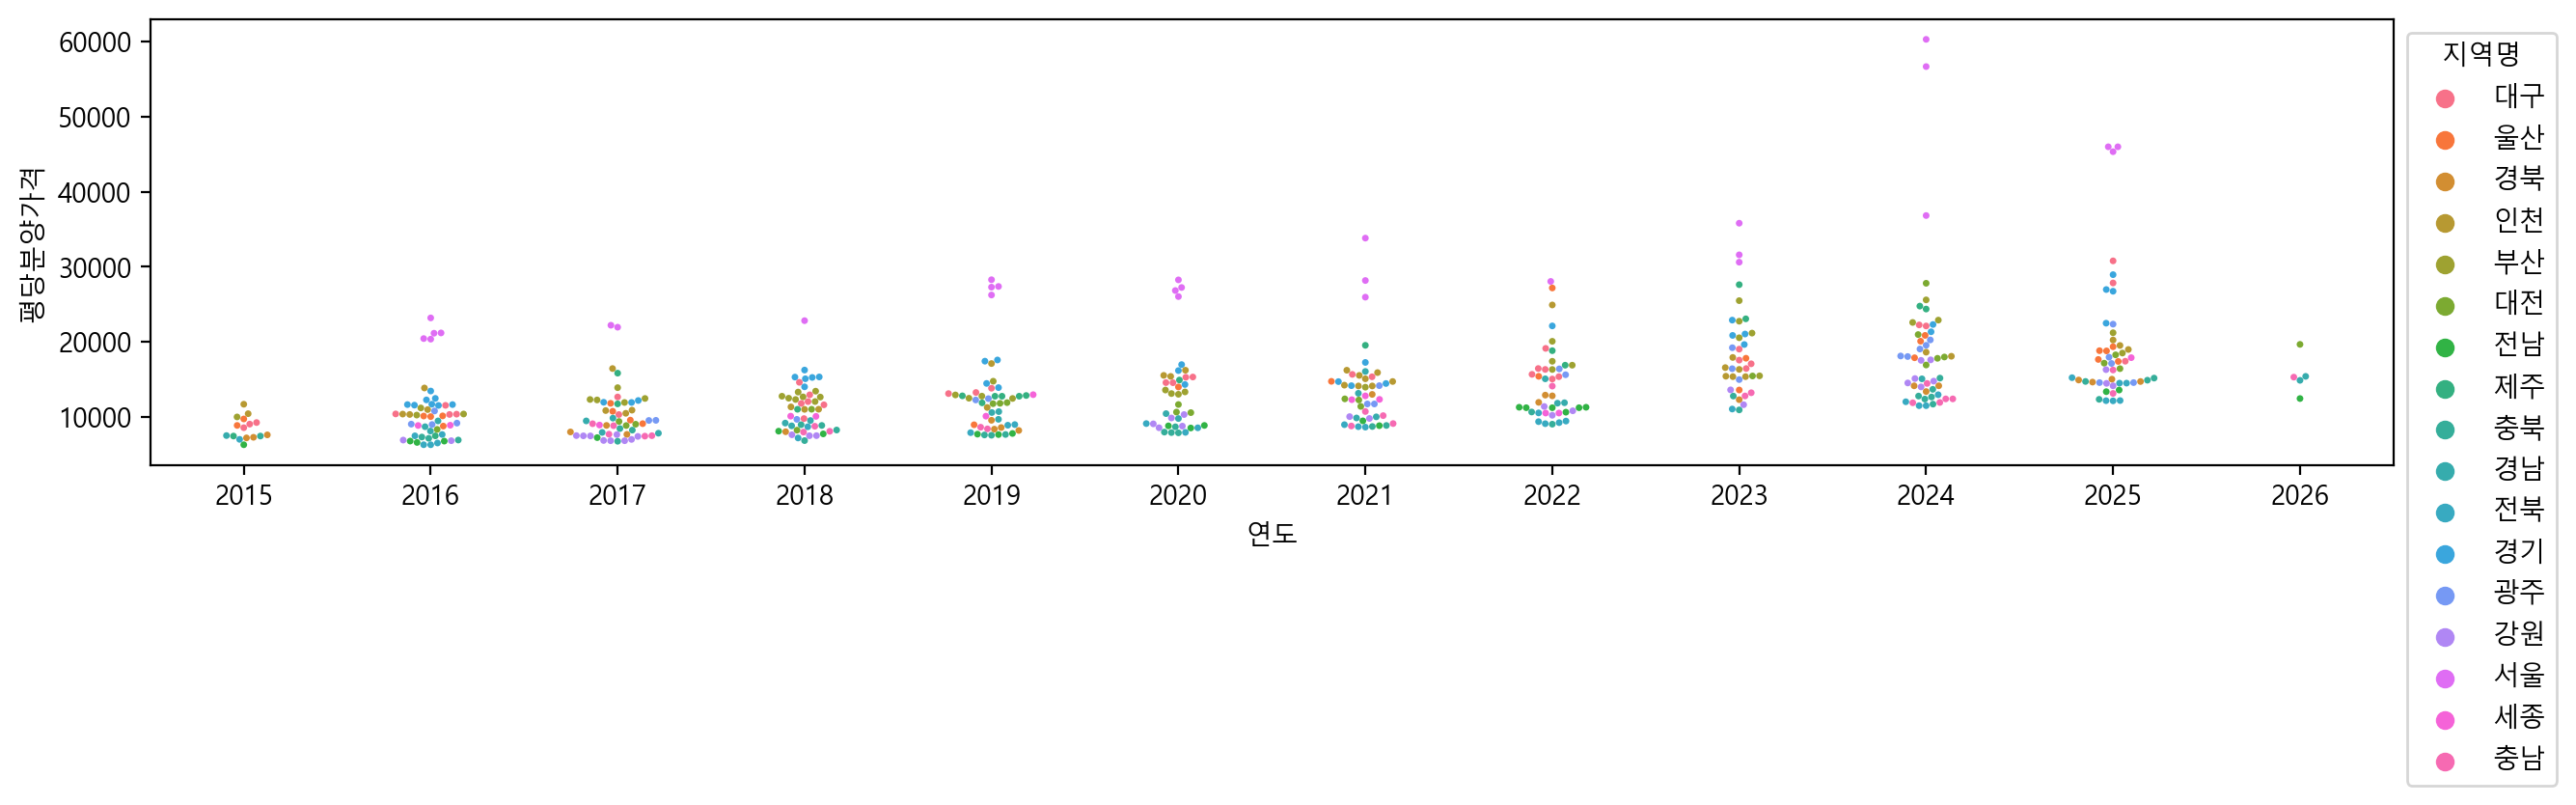

In [454]:
%%time
#df_last.sample(n=1000)
#df_last.sample(frac=0.05)    #몇 %를 뽑아
g=sns.swarmplot(data=df_last.sample(frac=0.05), x='연도', y='평당분양가격', size=2.5, hue='지역명')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용(교안 20page)

# 10. 구조가 다른 df_first와 df_last를 연결 후 분석
## (1) concat
- new_first :df_first를 [지역명, 연도, 월, 평당분양가격]으로 변환
- new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
                (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)

In [474]:
df_first=pd.read_csv('C:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',encoding='cp949')
df_first.head()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
1,부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
2,대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
3,인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,10016,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
4,광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231


In [475]:
new_first=df_first.melt(id_vars='지역',
                       var_name='연도월',
                       value_name='평당분양가격')
new_first.head(1)

,지역,연도월,평당분양가격
0,서울,2013년12월,18189


In [481]:
#지역 -> 지역명
#map이나 apply를 이용해서 연도와 월 컬럼 추가
new_first['연도']=new_first['연도월'].apply(lambda x : int(x.split('년')[0]))
new_first['연도'].head()
new_first['월']=new_first['연도월'].apply(lambda x : int(x.split('년')[1][:-1]))
new_first['월'].head()

0    12
1    12
2    12
3    12
4    12
Name: 월, dtype: int64

In [482]:
new_first.head()

,지역,연도월,평당분양가격,연도,월
0,서울,2013년12월,18189,2013,12
1,부산,2013년12월,8111,2013,12
2,대구,2013년12월,8080,2013,12
3,인천,2013년12월,10204,2013,12
4,광주,2013년12월,6098,2013,12


In [484]:
#연도월 컬럼을 drop(pop), 지역컬럼을 지역명으로 컬럼명 수정
new_first=new_first.drop('연도월',axis=1)
new_first

,지역,평당분양가격,연도,월
0,서울,18189,2013,12
1,부산,8111,2013,12
2,대구,8080,2013,12
3,인천,10204,2013,12
4,광주,6098,2013,12
...,...,...,...,...
352,전북,6580,2015,8
353,전남,6289,2015,8
354,경북,7037,2015,8
355,경남,7665,2015,8


In [487]:

new_first['지역명']=new_first['지역']
new_first=new_first.drop('지역',axis=1)

In [ ]:
#new_first.rename(columns={'지역':'지역명'})

In [488]:
new_first

,평당분양가격,연도,월,지역명
0,18189,2013,12,서울
1,8111,2013,12,부산
2,8080,2013,12,대구
3,10204,2013,12,인천
4,6098,2013,12,광주
...,...,...,...,...
352,6580,2015,8,전북
353,6289,2015,8,전남
354,7037,2015,8,경북
355,7665,2015,8,경남


In [493]:
# new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
#                 (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)
new_last=df_last[df_last['전용면적']=='모든면적']
new_last=new_last.drop('전용면적',axis=1)
new_last

,지역명,연도,월,평당분양가격
0,서울,2015,10,19275.3
5,인천,2015,10,10437.9
10,경기,2015,10,10355.4
15,부산,2015,10,10269.6
20,대구,2015,10,8850.6
...,...,...,...,...
10855,전북,2026,5,12714.9
10860,전남,2026,5,12490.5
10865,경북,2026,5,13549.8
10870,경남,2026,5,15450.6


In [505]:
df= pd.concat([new_first,new_last],axis=0)
df=df.reset_index(drop=True)

In [506]:
df[::1000]


,평당분양가격,연도,월,지역명
0,18189.0,2013,12,서울
1000,8847.3,2018,11,경북
2000,11922.9,2023,10,충남


## (2) 결측치 대체(연도별, 지역별 중위값)

In [507]:
df.isna().sum()

평당분양가격    35
연도         0
월          0
지역명        0
dtype: int64

In [511]:
df[df['평당분양가격'].isna()].count()

평당분양가격     0
연도        35
월         35
지역명       35
dtype: int64

In [512]:
df[df['평당분양가격'].isna()].head()

,평당분양가격,연도,월,지역명
1010,NaN,2018,12,울산
1027,NaN,2019,1,울산
1044,NaN,2019,2,울산
1061,NaN,2019,3,울산
1078,NaN,2019,4,울산


In [517]:
#연도별 지역별 중위값
fillnavalue=df.groupby(['연도','지역명'])['평당분양가격'].median().unstack()
fillnavalue = df.pivot_table(index='연도',columns='지역명',values='평당분양가격',aggfunc='median')
fillnavalue.loc[2018,'울산']

10312.5

In [519]:
def fillna_median(row):
    row=row.copy()
    year = row['연도']
    loc =row['지역명']
    #np.isnan(값), pd.isna(값), pd.isnull(값)
    if np.isnan(row['평당분양가격']):
        row['평당분양가격'] = fillnavalue.loc[year,loc]
    return row
fillna_median(df.loc[1010])


평당분양가격    10312.5
연도           2018
월              12
지역명            울산
Name: 1010, dtype: object

In [524]:
df=df.apply(fillna_median,axis=1)

In [525]:
df.isna().sum()

평당분양가격    0
연도        0
월         0
지역명       0
dtype: int64

In [526]:
df

,평당분양가격,연도,월,지역명
0,18189.0,2013,12,서울
1,8111.0,2013,12,부산
2,8080.0,2013,12,대구
3,10204.0,2013,12,인천
4,6098.0,2013,12,광주
...,...,...,...,...
2528,12714.9,2026,5,전북
2529,12490.5,2026,5,전남
2530,13549.8,2026,5,경북
2531,15450.6,2026,5,경남


## (3) df.csv파일로 출력

In [527]:
df.to_csv('data/df(최종).csv', index=False)

In [530]:
df.iloc[366:369]

,평당분양가격,연도,월,지역명
366,7151.1,2015,10,강원
367,6705.6,2015,10,충북
368,6926.7,2015,10,충남


## (4) 7절부터 9절까지 분석을 한다(전용면적별 분석은 불가)

- 지역명별 데이터 갯수는 결측치가 없어서 동일(groupby나 pivot_table등으로 확인)
- 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)
- 연도별 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)

### ① 지역명별 데이터 행 갯수 : 결과가 1차원 시리즈

### ② 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [ ]:
# 지역명당 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ③ 연도별 평당분양가격(평균)

In [ ]:
# 연도별 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ④ 연도, 지역별 평당분양가격(평균)

In [ ]:
# 연도별, 지역별 평당분양가격 시각화(heatmap)

In [ ]:
# 년도별 평균 평당분양가격의 추이

In [ ]:
# 위의 그래프가 겹쳐서 작 보이지 않아 분리

In [ ]:
# 관계형 그래프의 서브플롯을 그리는 함수는 relplot
# 범주형 그래프의 서브플롯을 그리는 함수는 catplot

In [ ]:
# 연도별 평당분양가격의 사분위수


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 boxenplot)


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 violinplot)


In [ ]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화


In [ ]:
# swarmplot은 많은 데이터를 그리기에는 시간이 많이 걸려 5%만 sampling후 그릴 것을 추천
# 연도별 평당분양가격 산점도
 

In [ ]:
# 분양가격을 hist
